# Predviđanje Raka Pluća 😷

---


## 0.Uvod

Ovaj projekat analizira podatke o pacijentima sa rakom pluća. Podaci obuhvataju različite faktore rizika, uključujući:
- starost,
- pol,
- izloženost zagađenju vazduha,
- konzumaciju alkohola,
- alergiju na prašinu,
- profesionalne rizike,
- genetsku predispoziciju,
- hronične plućne bolesti,
- uravnoteženu ishranu,
- gojaznost,
- pušenje,
- pasivno pušenje,
- bol u grudima,
- iskašljavanje krvi,
- umor,
- gubitak težine,
- otežano disanje,
- šištanje u grudima,
- otežano gutanje,
- deformaciju noktiju,
- hrkanje.

Rak pluća je vodeći uzrok smrtnosti od raka širom sveta, sa 1,59 miliona smrtnih slučajeva u 2018. godini. Iako je pušenje glavni uzrok raka pluća, sve više dokaza ukazuje na to da zagađenje vazduha može povećati rizik, čak i kod nepušača. Cilj ovog projekta je da istraži veze između ovih faktora i rizika od razvoja raka pluća koristeći dostupni skup podataka.


### Ideja projekta

Cilj mog projekta je predvideti verovatnoću razvoja raka pluća kod pacijenata na osnovu različitih faktora rizika, kao i identifikovati ključne faktore koji najviše doprinose tom riziku.


### Koraci za pokretanje projekta

#### 1. **Razumevanje i priprema podataka**
   - **Preuzimanje podataka**: Preuzmite dataset sa Kaggle-a.
   - **Pregled podataka**: Analizirajte strukturu podataka (`head()`, `info()`, `describe()` u Python-u) kako biste razumeli vrste promenljivih i nedostajuće vrednosti.
   - **Čišćenje podataka**: Obratite pažnju na nedostajuće vrednosti, nekonzistentne unose i outliere.
   - **Kodiranje podataka**: Ako imate kategorijalne promenljive (npr. pol), koristite metode kao što su one-hot encoding ili label encoding.

#### 2. **Eksploratorna analiza podataka (EDA)**
Eksploratorna analiza podataka (EDA) je proces istraživanja i vizualizacije podataka kako bi se otkrili njihovi osnovni obrasci, glavne karakteristike i odnosi, pre nego što se primene složenije analitičke metode.
   - **Vizuelizacija podataka**: Kreirajte grafikone za analizu distribucije podataka i odnosa između faktora rizika (npr. histogrami, scatter plotovi, box plotovi).
   - **Korelacija**: Izračunajte korelacije između faktora rizika i dijagnoze raka pluća.

#### 3. **Priprema za modelovanje**
   - **Brisanje outliers-a**: Obrisacemo outlier-e tj podatke koji su previsse razliciti od ostalih(ekstremne vrednost)
   - **Standardizacija/normalizacija**: Ako koristite algoritme koji zavise od skale podataka, standardizujte numeričke promenljive.
   - **Podela podataka**: Podelite podatke na trening i test set (npr. 80%-20%).
   - **Feature selection**: Odaberite najbintije faktore za modelovanje koristeći metode poput univariate selection-a.

#### 4. **Izbor i obuka modela**
   - Testirajte različite algoritme za klasifikaciju, poput:
     - Logistic Regression
     - Random Forest
     - Support Vector Machines (SVM)
     - Gradient Boosting (npr. XGBoost)
   - Upotrebite metodu validacije (npr. k-fold cross-validation) za procenu performansi modela.

#### 5. **Evaluacija modela**
   - Analizirajte ROC krivu i AUC vrednost za merenje performansi klasifikacionih modela.

#### 6. **Interpretacija i vizualizacija rezultata**
   - Kreirajte izveštaje i grafikone koji prikazuju rezultate analize i zaključke.
   - Identifikujte ključne faktore koji imaju najveći uticaj na rizik od raka pluća.

## 1.Razumevanje i priprema podataka

### 1.1.Preuzimanje podataka

Prvo cemo da rapskujemo ZIP fajl koji smo skinuli sa Kaggle web sajta https://www.kaggle.com/datasets/thedevastator/cancer-patients-and-air-pollution-a-new-link?resource=download

In [ ]:
# Kod koji nam pomze u raspakivanju koda
# !unzip <putanja_do_zip_fajla> -d <putanja_gde_zelimo_da_nam_raspakovani_fajlovi_budu>

#!unzip "/content/drive/MyDrive/Colab_Notebooks/LungCancer/archive.zip" -d "/content/drive/MyDrive/Colab_Notebooks/LungCancer/"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Deklaracija svih biblioteka koje cemo koristiti

In [ ]:
# Za razdvajanje podataka na trening i test skupove.
from sklearn.model_selection import train_test_split
# Za enkodiranje nasih klasa "Low", "Medium", "High" (Pretvaranje kategorijskih podataka u numeričke
from sklearn.preprocessing import LabelEncoder
# Uvoz funkcije za selekciju najboljih karakteristika (biranje najkorisnijih kolona)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
# Za implementaciju logističke regresije (model za binarnu ili višeklasnu klasifikaciju)
from sklearn.linear_model import LogisticRegression
# Za kreiranje Random Forest klasifikatora
from sklearn.ensemble import RandomForestClassifier
# Za korišćenje Support Vector Machine (SVM) modela
from sklearn.svm import SVC
# Importovanje klase XGBClassifier iz biblioteke xgboost
from xgboost import XGBClassifier
# Za ocenjivanje tacnosti modela (preciznosti predvidjanja)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
# Za standardizaciju podataka
from sklearn.preprocessing import StandardScaler
# Za unakrsnu validaciju modela
from sklearn.model_selection import cross_val_score
# Za racunanje ROC krive i AUC vrednosti
from sklearn.metrics import roc_curve, roc_auc_score
# Za binarizaciju oznaka (labela)
from sklearn.preprocessing import label_binarize
# Za vizuelizaciju matrice konfuzije, koja prikazuje performanse klasifikacionog modela kroz tabelu stvarnih i predviđenih klasa
from sklearn.metrics import ConfusionMatrixDisplay
# Ucitacemo funkciju za Over-sampling
from imblearn.over_sampling import SMOTE
# Importovanje funkcije plot_tree za vizualizaciju stabla odlučivanja
from sklearn.tree import plot_tree
# Izracunavanje Z-vrednosti (standardizovanih ocena)
from scipy.stats import zscore
# Za pretragu najboljih hiperparametara modela
from sklearn.model_selection import GridSearchCV


# Za rad sa XGBoost modelom
import xgboost as xgb
# Za rad sa LightGBM modelom
import lightgbm as lgb
# Za rad sa tabelarnim podacima (DataFrame, Series).
import pandas as pd
# Za kreiranje statičnih i interaktivnih grafika.
import matplotlib.pyplot as plt
# Za napredne statističke vizualizacije.
import seaborn as sns
# Za koriscenje matematickih funkcija
import math
# Korisna za rad sa velikim, visedimenzionalnim nizovima i matricama
import numpy as np

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


### 1.2. Pregled podataka

Analiza strukture podataka (`head()`, `info()`, `describe()`) kako bismo razumeli vrste promenljivih i nedostajuće vrednosti.

In [ ]:
CSV_PATH = "/content/drive/MyDrive/Colab_Notebooks/LungCancer/cancer patient data sets.csv" # Nas .csv fajl sa podacima koje cemo koristiti

data = pd.read_csv(CSV_PATH) # Citanje .csv fajla pomocu pandas biblioteke sa "CSV_PATH" putanje

data.head() # Ipis Prvih 5 linija iz .csv fajla

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High


In [ ]:
# Da vidimo koje sve kolone imamo u nasem .csv fajlu
data.columns

Index(['index', 'Patient Id', 'Age', 'Gender', 'Air Pollution', 'Alcohol use',
       'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk',
       'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking',
       'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue',
       'Weight Loss', 'Shortness of Breath', 'Wheezing',
       'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold',
       'Dry Cough', 'Snoring', 'Level'],
      dtype='object')


Ova tabela pruža detaljna objašnjenja svakog atributa sa tipom podataka koji olakšava analizu i obradu.


| Naziv kolone                 | Opis kolone                                              | Tip podataka       |
|-----------------------------------------|---------------------------------------------------------|--------------------|
|Index (Index)|Redni broj zapisa u datasetu, jedinstveni identifikator za svaki red|Numerički|
|Pacijent ID (Patient Id)|Jedinstveni identifikator pacijenta|Tekst (string)|
| Godine (Age)                            | Starost pacijenta u godinama                            | Numerički          |
| Pol (Gender)                            | Pol pacijenta (1 = Muško, 2 = Žensko)                   | Kategorijski       |
| Zagađenje vazduha (Air Pollution)       | Izloženost pacijenta zagađenju vazduha (1-10 skala)     | Numerički |
| Korišćenje alkohola (Alcohol use)       | Učestalost konzumacije alkohola (1-10 skala)            | Numerički |
| Alergija na prašinu (Dust Allergy)      | Intenzitet alergije na prašinu (1-10 skala)             | Numerički |
| Profesionalni rizici (Occupational Hazards) | Rizik povezan s radnim mestom (1-10 skala)              | Numerički |
| Genetski rizik (Genetic Risk)           | Nivo genetskog rizika za bolest (1-10 skala)            | Numerički |
| Hronična bolest pluća (Chronic Lung Disease) | Da li pacijent ima hroničnu bolest pluća (1-10 skala)   | Numerički |
| Uravnotežena ishrana (Balanced Diet)    | Učestalost uravnotežene ishrane (1-10 skala)            | Numerički |
| Gojaznost (Obesity)                     | Stepen gojaznosti pacijenta (1-10 skala)                | Numerički |
| Pušenje (Smoking)                       | Učestalost pušenja (1-10 skala)                         | Numerički |
| Pasivni pušač (Passive Smoker)          | Izloženost pasivnom pušenju (1-10 skala)                | Numerički |
| Bol u grudima (Chest Pain)              | Intenzitet bola u grudima (1-10 skala)                  | Numerički |
| Iskašljavanje krvi (Coughing of Blood)  | Da li pacijent iskašljava krv (1-10 skala)              | Numerički |
| Umor (Fatigue)                          | Nivo umora pacijenta (1-10 skala)                       | Numerički |
| Gubitak težine (Weight Loss)            | Da li pacijent ima neobjašnjiv gubitak težine (1-10 skala) | Numerički |
| Kratak dah (Shortness of Breath)        | Učestalost kratkog daha (1-10 skala)                    | Numerički |
| Šištanje (Wheezing)                     | Intenzitet šištanja pri disanju (1-10 skala)            | Numerički |
| Teškoće pri gutanju (Swallowing Difficulty) | Da li pacijent ima probleme pri gutanju (1-10 skala)    | Numerički |
| Zadebljanje noktiju (Clubbing of Finger Nails) | Prisustvo zadebljanja noktiju (1-10 skala)             | Numerički |
| Česte prehlade (Frequent Cold)          | Učestalost prehlada (1-10 skala)                        | Numerički |
| Suvi kašalj (Dry Cough)                 | Intenzitet suvog kašlja (1-10 skala)                    | Numerički |
| Hrkanje (Snoring)                       | Učestalost hrkanja (1-10 skala)                         | Numerički |
| Nivo (Level)                            | Kategorija rizika (Low, Medium, High)                  | Kategorijski       |


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   index                     1000 non-null   int64 
 1   Patient Id                1000 non-null   object
 2   Age                       1000 non-null   int64 
 3   Gender                    1000 non-null   int64 
 4   Air Pollution             1000 non-null   int64 
 5   Alcohol use               1000 non-null   int64 
 6   Dust Allergy              1000 non-null   int64 
 7   OccuPational Hazards      1000 non-null   int64 
 8   Genetic Risk              1000 non-null   int64 
 9   chronic Lung Disease      1000 non-null   int64 
 10  Balanced Diet             1000 non-null   int64 
 11  Obesity                   1000 non-null   int64 
 12  Smoking                   1000 non-null   int64 
 13  Passive Smoker            1000 non-null   int64 
 14  Chest Pain               

1. **Broj uzoraka (count)**:
   - Za sve kolone, vrednost `count` je 1000, što znači da ne postoje nedostajuće vrednosti u datasetu. Ovo je odličan signal za konzistentnost podataka.

2. **Prosek (mean)**:
   - Većina ordinalnih kolona (1-10 skala) ima prosečne vrednosti bliske sredini (oko 4-5). Ovo ukazuje na to da su podaci ravnomerno raspodeljeni oko srednje vrednosti.
   - Starost pacijenata (`Age`) ima prosečnu vrednost 37, što ukazuje da je uzorak uglavnom iz populacije srednje starosne dobi.

3. **Standardna devijacija (std)**:
Standardna devijacija meri prosečno odstupanje vrednosti od srednje vrednosti. Kada je standardna devijacija veća, to implicira da se vrednosti više razlikuju od proseka.
   - Veće standardne devijacije za neke kolone, poput `Coughing of Blood` (2.42) i `Fatigue` (2.24), ukazuju na širi raspon vrednosti i veću varijabilnost(raznovrsnost) među pacijentima.
   - Starost (`Age`) ima relativno visok standardni devijaciju (12.00), što ukazuje na raznovrsnost starosne populacije.

4. **Minimalne i maksimalne vrednosti (min, max)**:
   - Većina ordinalnih kolona ima vrednosti od 1 do 8 ili 9, što odgovara definisanoj skali. Nema nevažećih vrednosti.
   - Starost ima minimalnu vrednost 14 i maksimalnu 73, što ukazuje da uzorak ne uključuje decu i veoma staru populaciju.

5. **Kvartili (25%, 50%, 75%)**:
   - Većina ordinalnih kolona ima medijane (50%) i interkvartilne raspone (25%-75%) koji ukazuju na relativno simetrične raspodele podataka.
   - Za starost (`Age`), medijan je 36 godina, dok 75% populacije ima manje od 45 godina, što ukazuje na blagu pristrasnost ka mlađoj populaciji.


Ključni zaključci:
1. **Nema nedostajućih vrednosti.**
2. **Demografija uzorka**:
   - Starost pacijenata je koncentrisana u srednjim godinama.
   - Pol je ravnomerno zastupljen, sa vrednostima 1 i 2.

### 1.3.Čišćenje podataka

Posto u nasem data setu ne postoje kolone sa nedostajucim vrednostima ne moramo se baviti resavanjem tog problema.

A sto se tice `outliera` to cemo videti kasnije kada budemo vizuelno prikazati podatke (tada ce biti lakse uociti ih).

Sada cemo samo izbaciti kolone koje nemaju uticaja na dalju analizu.

In [ ]:
# Posto biblioteka pandas nas .csv fajl transformise u DataFrame i on automacki
# stvara indekse "index" kolona nam je suvisna pa cemo je obisati/izbaciti
data = data.drop(columns=["index"])

# Takodje mislim da ID pacijenta nema niakav uticaj na to da li je on u riziku
# od bolesti ili ne pa cemo i tu kolonu da izbacimo
data = data.drop(columns=["Patient Id"])

data.head()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,Low
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,High
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High


### 1.4.Kodiranje podataka




U nasem data setu pol je vec u numerickom formatu ali cemo ga svakako transformisati.

Da bismo izbegli zabunu modela zbog numerickih vrednosti u `Gender` koloni, mozemo da mapiramo postojece vrednosti tako da `1` ostane `1`, dok `2` postane `0`. Ovo ce jasno oznaciti da su to binarne kategorije, a ne kontinualne vrednosti.

Ovo je korisno za modele koji bi mogli interpretirati 1 i 2 kao kontinualne vrednosti. Neki od tih modela su:
- Logistička regresija,
- K najbližih suseda (KNN),
- Podrška vektorske mašine (SVM)

In [ ]:
# Mapiranje vrednosti u 'Gender' koloni: 1 -> 1, 2 -> 0
data['Gender'] = data['Gender'].map({1: 1, 2: 0})

# Provera rezultata
print(data['Gender'].value_counts())

Gender
1    598
0    402
Name: count, dtype: int64


In [ ]:
data.head()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,Low
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,High
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High


A sto se tice kodiranja "Level" kolone to cemo uraditi kasnije da nam ne uticalo na nasu analizu.

Na primer kada su klase tekstualne (npr. "Low", "Medium", "High"), mozemo lako interpretirati/tumaciti njihova znacenja. Ako ih kodiramo u numericke vrednosti (npr. 0, 1, 2), to moce stvoriti nepotrebnu konfuziju i uticati na interpretaciju podataka (jer vidimo samo brojke i ne znamo sta znace). U analizi, zelimo da jasno vidimo koja klasa oznacava koji nivo rizika, bez toga da brojke sugerisu neko znacenje koje nije prisutno.

---

## 2.Eksploratorna analiza podataka (EDA)

Kreiranje grafikona za analizu distribucije podataka i odnosa izmedju faktora rizika (npr. histogrami, scatter plotovi, box plotovi).

Uzecemo na pirmer za pocetak da vidimo koliko imamo muskaraca i zena u nasem dataset-u

In [ ]:
data["Gender"].value_counts()

,count
Gender,
1,598
0,402


 Sada da vidimo raspodele klasa u ciljnoj promenljivoj (`Level`) i vidimo da li postoji problem sa neuravnotezenim klasama.

In [ ]:
data["Level"].value_counts()

,count
Level,
High,365
Medium,332
Low,303


Posto balansiranje dataset-a obicno se primenjuje kada postoji znacajna neravnoteza između klasa u ciljnim/target varijablama (`Level` u nasem slucaju), a ne za feature varijable kao sto je Pol na primer. A i broj muskaraca i zena u ovom dataset-u prilicno blizak (598 naspram 402), verovatno nije potrebno balansirati ovaj skup podataka, jer razlika nije znacajna.

### 2.1.Vizuelizacija podataka

Da vidimo vizuelno raspodele klasa pomocu `countplot`-a

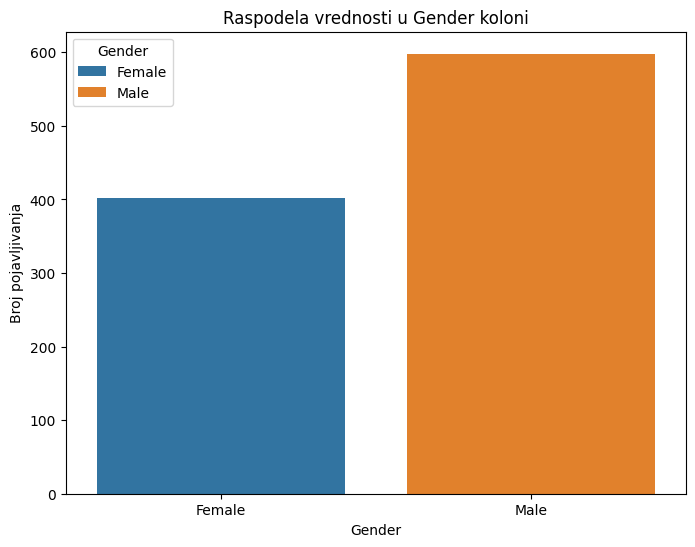

In [ ]:
# Distribucija ciljane promenljive 'Gender'
plt.figure(figsize=(8, 6))

# Kreiranje grafa za brojanje vrednosti u koloni 'Gender'
sns.countplot(data=data, x='Gender', hue="Gender")

# Postavljanje prilagođenih oznaka za x-osu
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])  # Zamena 0 i 1 sa "Female" i "Male"

# Postavljanje prilagođenih oznaka za legendu
plt.legend(title="Gender", labels=['Female', 'Male'])  # Zamena oznaka u legendi

# Dodavanje naslova i oznaka osa
plt.title("Raspodela vrednosti u Gender koloni")
plt.xlabel("Gender")
plt.ylabel("Broj pojavljivanja")

# Prikaz grafa
plt.show()


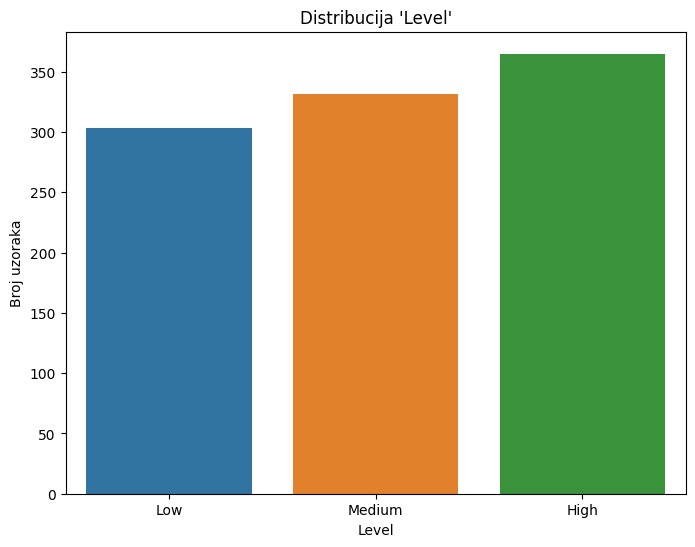

In [ ]:
# Distribucija ciljane promenljive 'Level'
plt.figure(figsize=(8, 6))

sns.countplot(data=data, x='Level', hue="Level")
plt.title("Distribucija 'Level'")
plt.xlabel("Level")
plt.ylabel("Broj uzoraka")

plt.show()

Vidimo blagu neuravnotezenost izmedju klasa.

Klasa "High" ima vecu vrednost (365) u odnosu na klase "Medium" (332) i "Low" (303). U slucaju kada je jedna klasa dominantnija model moze da favorizuje tu klasu na stetu ostalih klasa.

Da bi izbalansirali nase klase koristiti metode `under-sampling` ili `over-sampling`.

U kontekstu medicinskih podataka kao sto mi imamo ovde, obe metode imaju svoje prednosti i mane/rizike:

1. **Under-sampling**: smanjenjuje broja uzoraka u vecinskoj klasi kako bi se postigla ravnoteza izmedju klasa.

- *Prednosti* :
    - Brže treniranje modela: Smanjenjem broja uzoraka, model moze brze da se trenira, sto moze biti korisno kada imamo velike setove podataka.
- *Mane* :
    - *Gubitak važnih informacija*: Kada smanjujete broj uzoraka u vecinskoj klasi, moze se desiti da izgubite korisne informacije. U medicinskim podacima, ove informacije mogu biti kljucne za tacno predviđanje i razumevanje stanja pacijenta.
2. Over-sampling: podrazumeva povecanje broja uzoraka u manjinskoj klasi, cime se generisu sintetički uzorci.

- *Prednosti* :
    - Očuvanje informacija: Sa over-samplingom, zadrzavamo sve uzorke iz vecinske klase, dok generisemo nove uzorke za manjinske klase, cime se ocuvavaju svi podaci.
    - Bolja generalizacija: U mnogim slucajevima, generisanje novih uzoraka pomaze modelu da bolje generalizuje, jer uci iz veceg broja uzoraka.
- *Mane* :
    - Sinteticki podaci: SMOTE (funkcija sa kojom generisemo podatke) generise sinteticke uzorke, koji mogu biti previse slicni postojecim podacima, sto moze dovesti do pretreniranja (overfitting) modela.
    - Mogući problemi sa validnoscu: Generisanje sintetickih/vestackih uzoraka moze ponekad stvoriti podatke koji nisu potpuno reprezentativni za stvarni svet, posebno u medicinskim podacima, gde je tacnost kriticna.


Zakljucak:


  **Over-sampling** (pomocu funkcije SMOTE) je obicno bolja opcija za medicinske podatke, jer omogucava da sacuvamo sve informacije o vecinskoj klasi dok generisemo nove uzorke za manjinske klase. Medjutim, potrebno je pazljivo pristupiti validaciji modela i koristiti odgovarajuce tehnike kako bi se izbegao overfitting.

In [ ]:
# Razdvojicemo nase podatke na nezavisne promenljive (X) i ciljne/zavisne promenljive (y)
X = data.drop('Level', axis=1)  # Svi podaci osim ciljne promenljive 'Level'
y = data['Level']  # Ciljna promenljiva je 'Level'

In [ ]:
# Inicijalizacija SMOTE-a
smote = SMOTE(random_state=42)

# Primena SMOTE-a na dataset-u (generisanje sintetickih uzoraka za manjinske klase)
X_resampled, y_resampled = smote.fit_resample(X, y)
# Proveri broj uzoraka u svakoj klasi nakon SMOTE-a
print(f"Sada nam broj pojedinacnih klasa izgelda ovako:\n\n{pd.Series(y_resampled).value_counts()}")

Sada nam broj pojedinacnih klasa izgelda ovako:

Level
Low       365
Medium    365
High      365
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [ ]:
# Mozemo sacuvati balansirani dataset u novi CSV fajl da bi odvojili originalan data set od novo-kreiranog:
balanced_dataset = X_resampled.copy()
balanced_dataset['Level'] = y_resampled

# Sačuvaj balansirani dataset u novi CSV
PATH_TO_NEW_DATA = "/content/drive/MyDrive/Colab_Notebooks/LungCancer/balansirani_podaci.csv"
balanced_dataset.to_csv(PATH_TO_NEW_DATA, index=False)

In [ ]:
# Sada kada imamo uravnotezenije podatke hajde da ucitamo taj .csv fajl i vidimo kako izgelda
CSV_PATH = "/content/drive/MyDrive/Colab_Notebooks/LungCancer/balansirani_podaci.csv"

data = pd.read_csv(CSV_PATH)

data.head()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,Low
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,High
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High


In [ ]:
data.describe()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring
count,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,...,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000
mean,37.182648,0.587215,3.738813,4.441096,5.064840,4.755251,4.484932,4.311416,4.395434,4.337900,...,4.721461,3.748858,3.778082,4.150685,3.715068,3.677626,3.845662,3.472146,3.802740,2.875799
std,12.150469,0.492560,2.014413,2.607813,2.009665,2.116015,2.136456,1.854095,2.133518,2.120022,...,2.413029,2.203939,2.190864,2.271382,2.011644,2.247729,2.389212,1.818778,2.007616,1.469093
min,14.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,27.000000,0.000000,2.000000,2.000000,3.500000,3.000000,2.000000,3.000000,2.000000,3.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,35.000000,1.000000,3.000000,4.000000,6.000000,5.000000,5.000000,4.000000,4.000000,4.000000,...,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000
75%,45.000000,1.000000,6.000000,7.000000,7.000000,7.000000,7.000000,6.000000,7.000000,7.000000,...,7.000000,5.000000,6.000000,6.000000,5.000000,5.000000,5.000000,4.000000,5.000000,4.000000
max,73.000000,1.000000,8.000000,8.000000,8.000000,8.000000,7.000000,7.000000,7.000000,7.000000,...,9.000000,9.000000,8.000000,9.000000,8.000000,8.000000,9.000000,7.000000,7.000000,7.000000


Vidimo da imamo `95` novih podataka (`count = 1095`).

In [ ]:
# Da vidimo broj pojedinacnih klasa:
data["Level"].value_counts()

,count
Level,
Low,365
Medium,365
High,365


Da vidimo sada kako izgleda raspodela "Level" kolone:


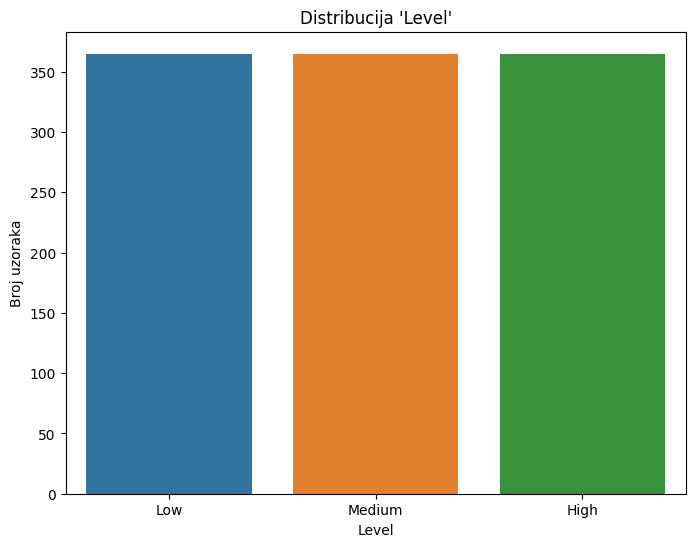

In [ ]:
# Da ponovo vidimo distribucija ciljane promenljive 'Level'
plt.figure(figsize=(8, 6))

sns.countplot(data=data, x='Level', hue="Level")
plt.title("Distribucija 'Level'")
plt.xlabel("Level")
plt.ylabel("Broj uzoraka")

plt.show()

Sada vidimo da su klase balansirane(imaju isti broji ponavlajanja)

Kreiraecmo histogram za sve numeričke kolone

Prvo cemo da ih izdvojimo u jednoj promenljivoj `numerical_columns`

In [ ]:
numerical_columns = data.select_dtypes(include=['int64']).columns

print(f"Postoji: {len(numerical_columns)} numerickih kolona\nOne su: \n{numerical_columns}")

Postoji: 23 numerickih kolona
One su: 
Index(['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
       'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease',
       'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain',
       'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath',
       'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails',
       'Frequent Cold', 'Dry Cough', 'Snoring'],
      dtype='object')


Izbacicemo "Gender" kolonu posto nam je to binarna kolona (ima samo 2 vrednosti) pa nam nece mnogo pomoci i ako je iscrtamo

In [ ]:
numerical_columns = numerical_columns.drop(["Gender"])

numerical_columns

Index(['Age', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
       'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease',
       'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain',
       'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath',
       'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails',
       'Frequent Cold', 'Dry Cough', 'Snoring'],
      dtype='object')

Da bi sto efikasnija i lakse nacrtali grafikon za svaku numericku kolonu hajde da vidimo koliko cemo linija a koliko kolona imati:


In [ ]:
# Izračunavamo broj redova i kolona za subgrafike
NUM_COLUMNS = 4  # Broj kolona
NUM_ROWS = math.ceil(len(numerical_columns) / NUM_COLUMNS)  # Broj redova zavisi od broja kolona

print(f"Broj linija {NUM_ROWS}\nBroj kolona {NUM_COLUMNS}")

Broj linija 6
Broj kolona 4


Histogrami se koriste za prikazivanje distribucije(kako su rasprostanjene) vrednosti numerickih podataka. Oni pokazuju ucestalost (frekvenciju) po opsegu vrednosti. (znaci ide redom i crta koliko vrednosti ima od jedne vrednosti do druge, pa od druge do trece i tako dalje)

In [ ]:
def drow_hist_for_num_columns(data, numerical_columns):
  plt.figure(figsize=(15, 10))

  for i, column in enumerate(numerical_columns, 1):
      plt.subplot(NUM_ROWS, NUM_COLUMNS, i)  # Podesiti broj redova i kolona prema broju atributa
      sns.histplot(data[column], kde=True, bins=30, color='blue')
      plt.title(f"Distribucija {column}")
      plt.xlabel(column)
      plt.ylabel("Frekvencija")
  plt.tight_layout()
  plt.show()

Box plot je vrlo koristan za prikazivanje raspodele numeričkih podataka, identifikaciju outliera (ekstremnih vrednosti) i statistickih pokazatelja (medijana, kvartili).

In [ ]:
def drow_box_for_num_column(data, numerical_columns):
  plt.figure(figsize=(50, 25))

  for i, column in enumerate(numerical_columns, 1):
      plt.subplot(NUM_ROWS, NUM_COLUMNS, i)  # Prilagoditi broj redova i kolona prema broju atributa
      sns.boxplot(data=data, x='Level', y=column, hue="Gender")
      plt.title(f"{column} u zavisnosti od 'Level'")
      plt.xlabel('Level')
      plt.ylabel(column)
  plt.tight_layout()
  plt.show()


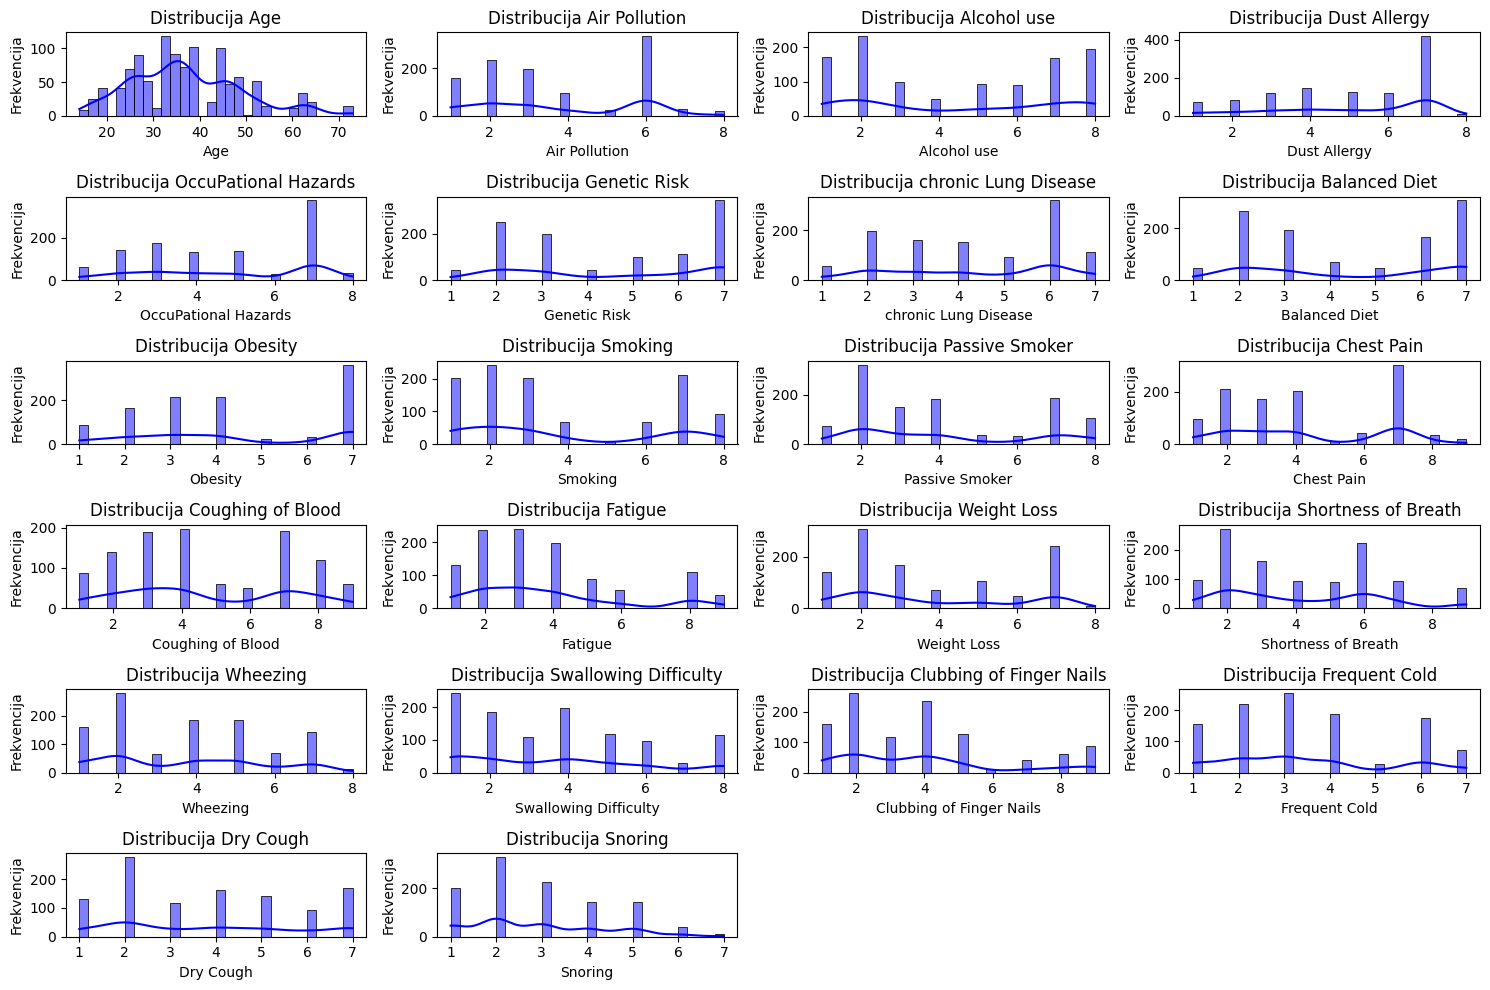

In [ ]:
drow_hist_for_num_columns(data, numerical_columns)

Takodje cemo i ovde izdvojiti samo jedan `histplot` da bi lakse objasnili koje su njegove karakteristike.

In [ ]:
def plot_one_histplot(data, column):

  # Racunanje kljucnih statistika
  mean = data[column].mean()
  median = data[column].median()
  mode = data[column].mode()[0]

  # Crtanje grafika(plot-a)
  plt.figure(figsize=(8, 6))
  sns.histplot(data=data, x=column, bins=30, kde=True, color='blue')

  # Dodavanje vertikalnih linija za vrednosti statistike
  plt.axvline(mean, color='red', linestyle='--', linewidth=1, label=f'Mean: {mean:.2f}')
  plt.axvline(median, color='green', linestyle='-', linewidth=1, label=f'Median: {median:.2f}')
  plt.axvline(mode, color='purple', linestyle=':', linewidth=1, label=f'Mode: {mode:.2f}')

  # Dapdavanje naslova, text za X i Y osu i legendu
  plt.title(f"Histplot vrenosti za kolonu {column}", fontsize=14)
  plt.xlabel("Vrednosti", fontsize=12)
  plt.ylabel("Frekfenca", fontsize=12)
  plt.legend(loc='upper left')  # Dodavenje legende za linije

  # Prikaz plot-a
  plt.show()


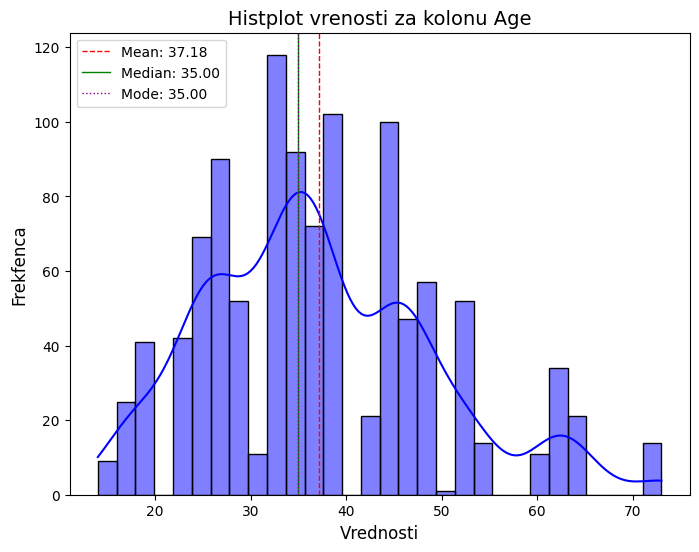

In [ ]:
plot_one_histplot(data, "Age")

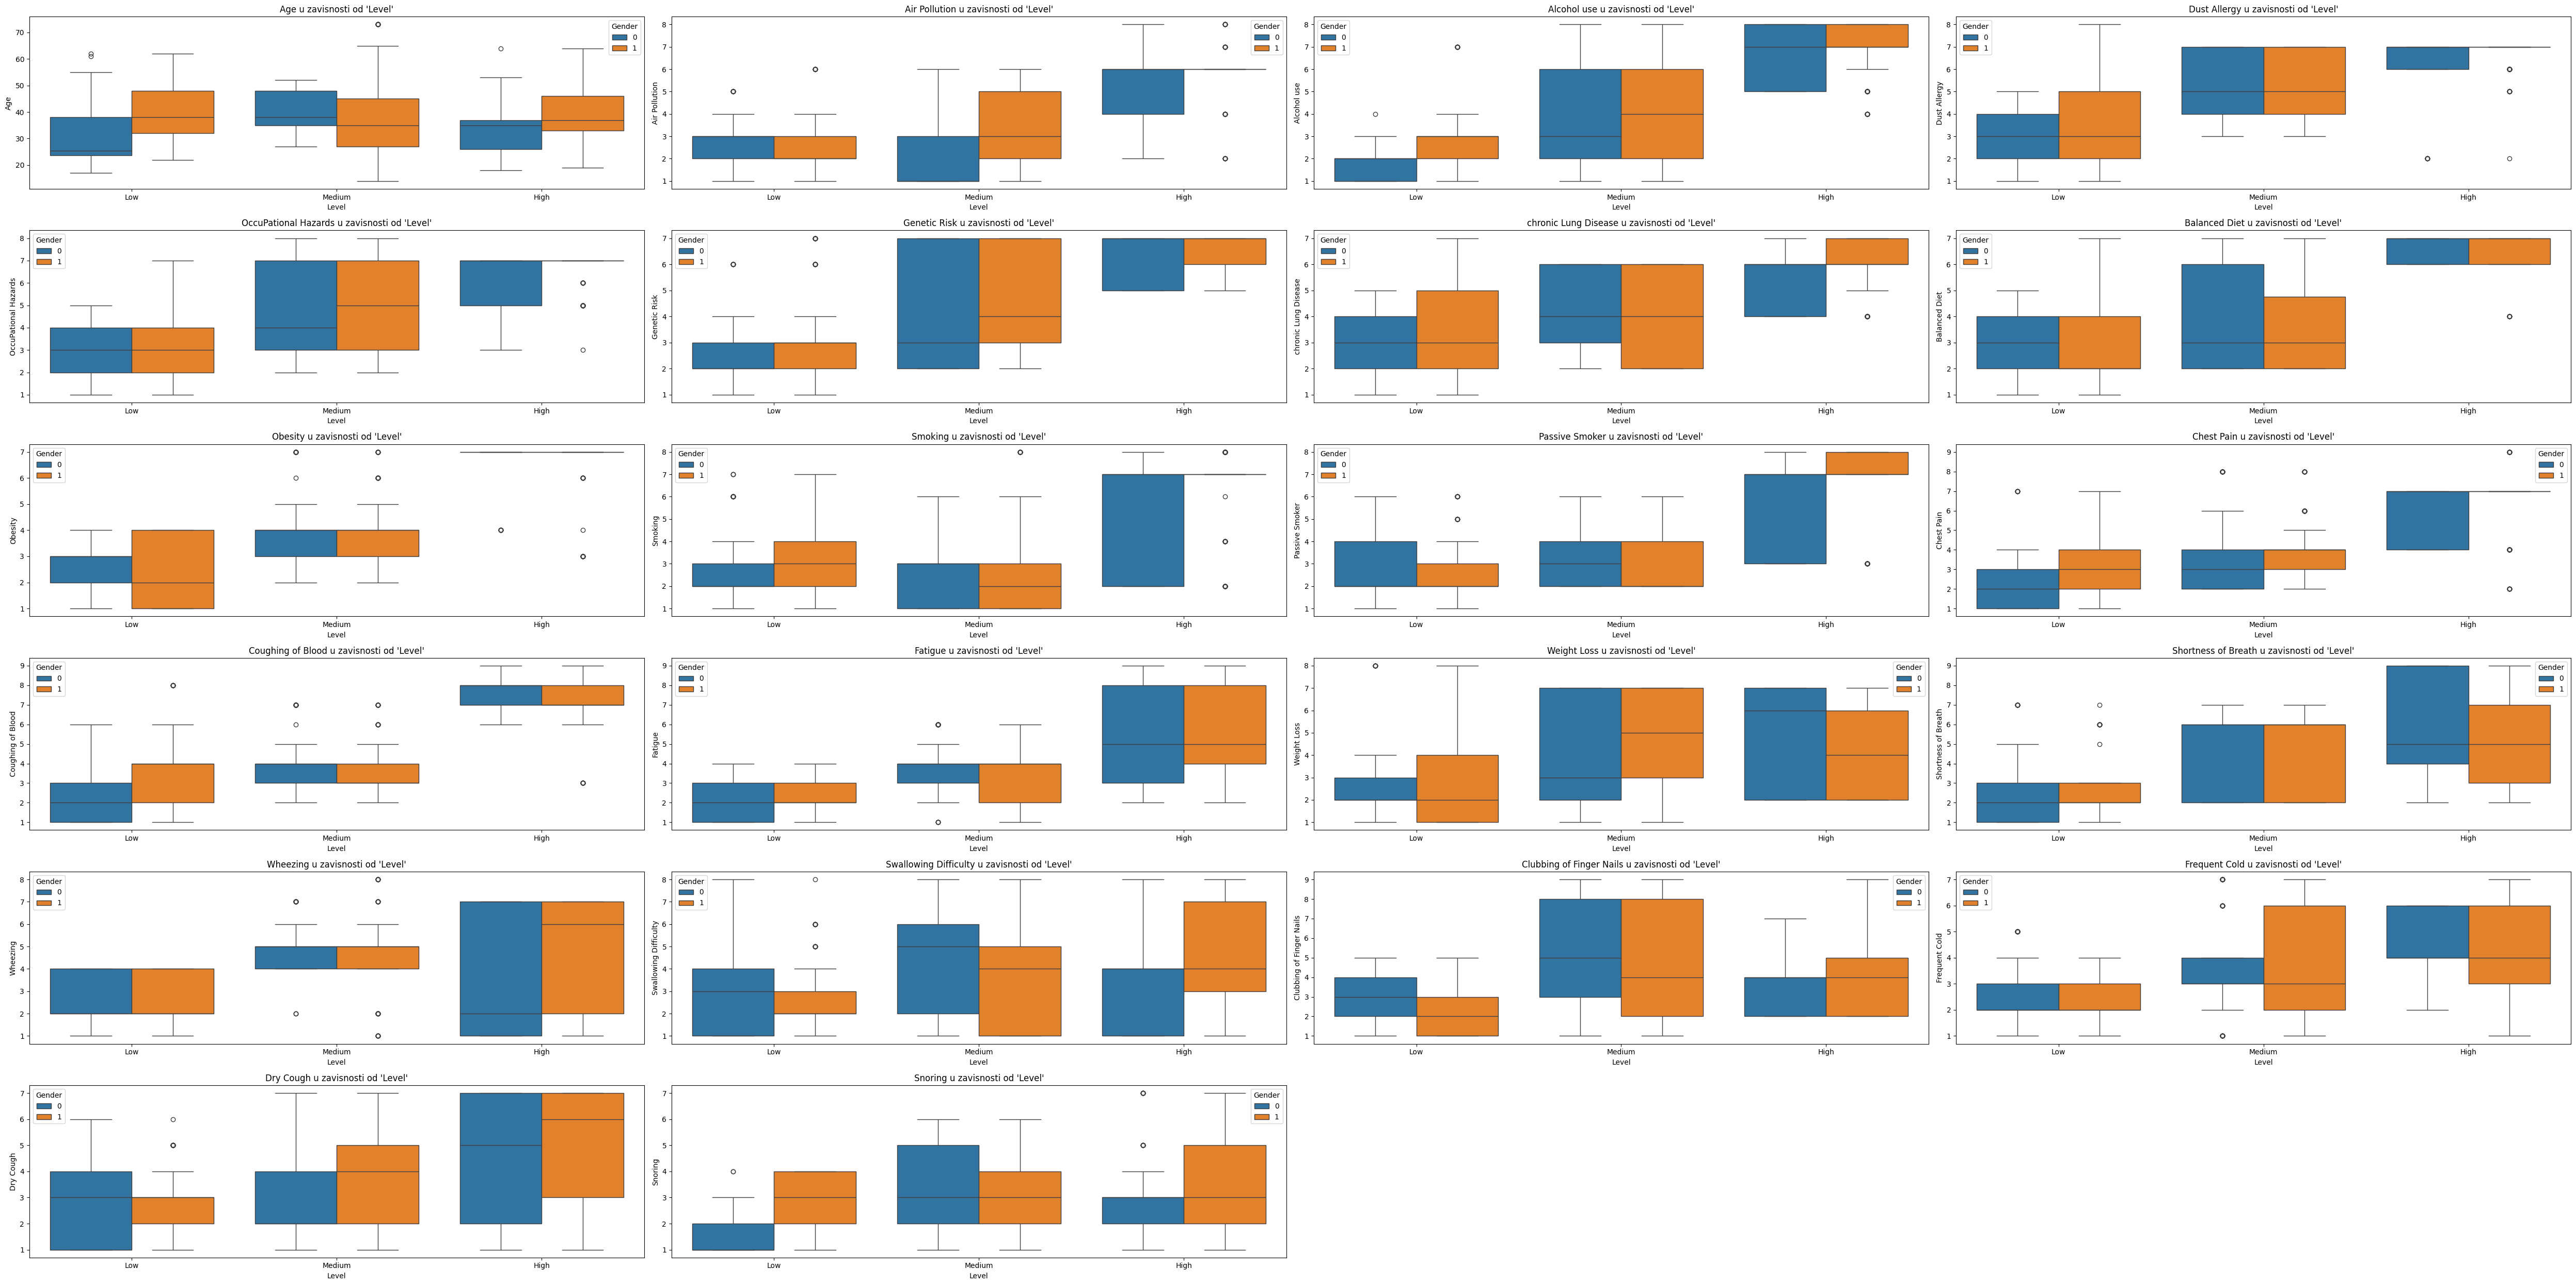

In [ ]:
drow_box_for_num_column(data, numerical_columns)

Da bi lakse razulemi ove `boxplot`-ove nacrtacemo samo jedan i obeleziti sve karakteristike na njemu:

In [ ]:
def plot_one_boxplot(data, column):
  data = data[column]
  # Kreiranje boxplot-a
  fig, ax = plt.subplots(figsize=(8, 6))
  box = ax.boxplot(data, patch_artist=True, vert=True, widths=0.5)

  # RAcunanje vrednosti
  stats = {
      "min": data.min(),
      "q1": data.quantile(0.25),
      "median": data.median(),
      "q3": data.quantile(0.75),
      "max": data.max()
  }

  # Izracunacemo "IQR" i "whisker" granice
  iqr = stats["q3"] - stats["q1"]
  whisker_low = max(stats["min"], stats["q1"] - 1.5 * iqr)
  whisker_high = min(stats["max"], stats["q3"] + 1.5 * iqr)

  # Print additional information
  print(f"\nStatistika za kolonu '{column}':")
  print("-" * 40)
  for key, value in stats.items():
      print(f"{key.upper():>8}: {value:>10.2f}")
  print("-" * 40)
  print(f"{'IQR':>8}: {iqr:>10.2f}")
  print(f"{'Donja Whisker':>8}: {whisker_low:>10.2f}")
  print(f"{'Gornja Whisker':>8}: {whisker_high:>10.2f}")

  # Dodacemo etikete
  for key, value in stats.items():
      ax.text(1.1, value, f'{key}: {value:.2f}', ha='center', color='blue', fontsize=10)

  # Customize the boxplot appearance
  ax.set_title("Boxplot sa kljucnim statistickim karakteristikama", fontsize=14)
  ax.set_xticks([])
  ax.set_ylabel("Vrednosti")

  # Display the plot
  plt.show()



Statistika za kolonu 'Age':
----------------------------------------
     MIN:      14.00
      Q1:      27.00
  MEDIAN:      35.00
      Q3:      45.00
     MAX:      73.00
----------------------------------------
     IQR:      18.00
Donja Whisker:      14.00
Gornja Whisker:      72.00


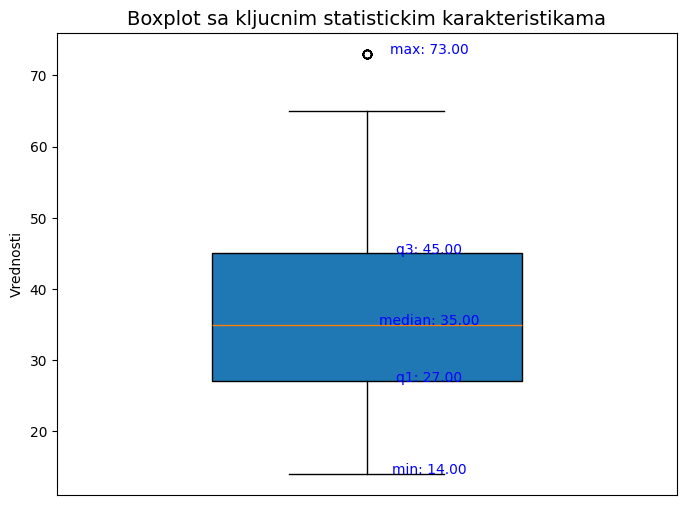

In [ ]:
plot_one_boxplot(data, "Age")

A ova funkcija ce nam nacrtati samo jedan box plot za svaku od kategorija za svaki pol:

In [ ]:
def draw_box_for_one_column_by_gander(data, column, figsize=(8, 6)):
    plt.figure(figsize=figsize)
    sns.boxplot(data=data, x='Level', y=column, hue="Gender")
    plt.title(f"{column} u zavisnosti od 'Level'")
    plt.xlabel('Level')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

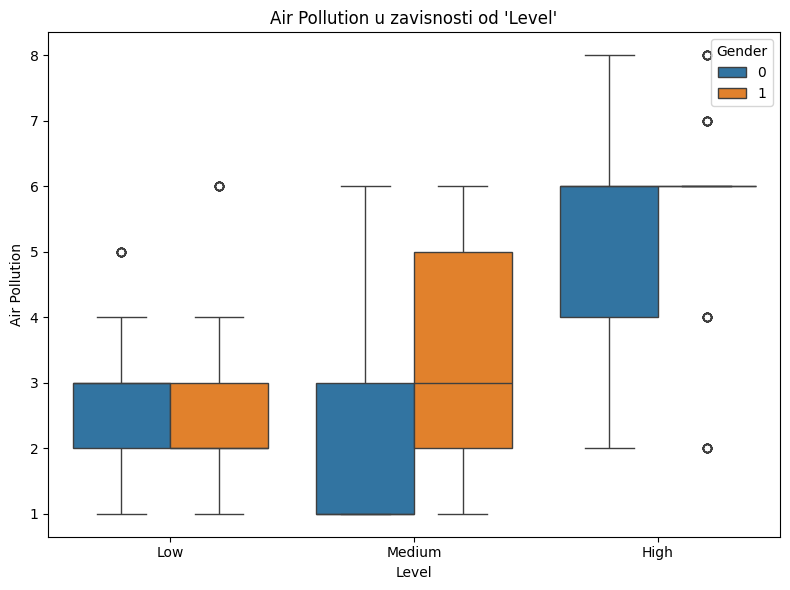

In [ ]:
draw_box_for_one_column_by_gander(data=data, column='Air Pollution')

### 2.2.Korelacija

Da bi mogli da odradimo korelaciju potrebno je da nase kategosirke vrednosti iz "Level" transformisemo u numericke.

In [ ]:
# Kreiraj LabelEncoder objekat
label_encoder = LabelEncoder()

# Pretvori 'Level' u numeričke vrednosti
data['Level'] = label_encoder.fit_transform(data['Level'])

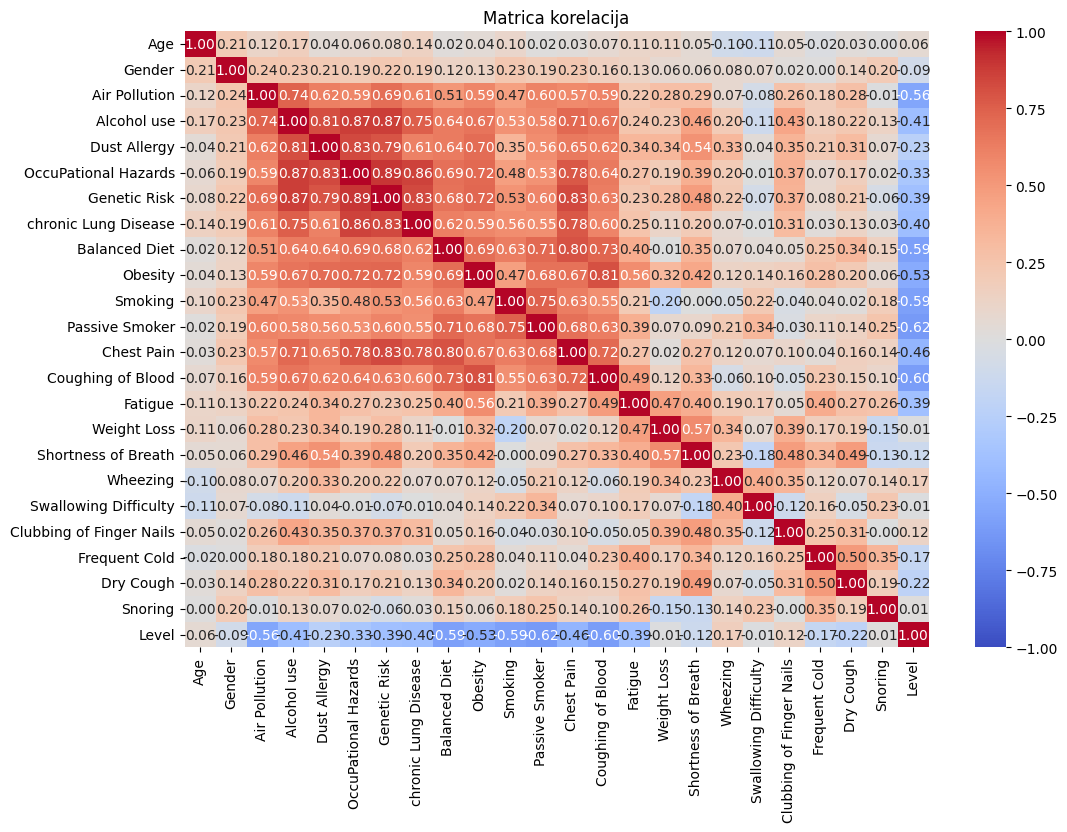

In [ ]:
# Sada možeš da izračunaš korelaciju
correlation_matrix = data.corr()

# Vizualizacija korelacija pomoću heatmap-a
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrica korelacija")
plt.show()

Prikazuje odnose izmedju razlicitih zdravstvenih i lifestyle faktora.

Ovo je toplotna mapa (`heatmap`) koja pokazuje medjusobne veze izmedju 21 razlicite varijable povezane sa zdravstvenim stanjem i zivotnim navikama. Vrednosti korelacije se krecu od -1 (tamno plava, savrsena negativna korelacija, to znaci ako se jedna vrednost poromeni druga ce se smanjiti) do +1 (tamno crvena, savrsena pozitivna korelacija, to znaci da ako se jedna vrednost poveca i druga ce se povecati).

Najvazniji uvidi iz matrice:

1. Najjace pozitivne korelacije:
- Alkohol i zagadenje vazduha (0.74)
- Alergija na prasinu i konzumiranje alkohola (0.81)
- Profesionalni rizici i genetski rizik (0.89)
- Hronicna plucna bolest i genetski rizik (0.83)

2. Znacajne negativne korelacije:
- Godine starosti (Age) i vecina drugih faktora pokazuju blage do umerene negativne korelacije
- Pol (Gender) pokazuje slabe do umerene negativne korelacije sa nekoliko faktora

3. Posebno interesantni klasteri:
- Grupa respiratornih simptoma (kasalj, otezano disanje, zvizdanje u plucima) pokazuje medjusobnu pozitivnu korelaciju
- Lifestyle faktori (pusenje, pasivno pusenje, konzumiranje alkohola) formiraju klaster sa umerenim do jakim pozitivnim korelacijama

4. Interpretacija boja:
- Crvene nijanse: pozitivna korelacija (varijable se krecu u istom smeru)
- Plave nijanse: negativna korelacija (varijable se krecu u suprotnim smerovima)
- Svetlije nijanse: slabija korelacija
- Tamnije nijanse: jaca korelacija

5. Dijagonala:
- Dijagonala matrice je uvek 1.00 (tamno crvena) jer predstavlja korelaciju varijable sa samom sobom

Ova matrica je posebno korisna za:
- Identifikovanje faktora rizika koji su medjusobno povezani
- Razumevanje kako razliciti zdravstveni simptomi mogu biti međusobno povezani
- Planiranje preventivnih zdravstvenih mera

U kontekstu masinskog ucenja, ovakva korelaciona matrica je izuzetno vazna za:
- Feature selection (izbor znacajnih karakteristika)
- Dimenzionalnost redukciju (izabracemo samo najvaznije faktore a ostale zanemariti)
- Razumevanje kako varijable zavise jedna od druge pre treniranja modela

## 3.Priprema za modelovanje

### 3.1.Brisanje outlier-a

Sada cemo obisati ekstremne vrednosti za svaku od kolona. Brisanje outliera(ekstremnih) pri izradi modela za masinsko ucenje poboljsava tacnost modela smanjenjem uticaja ekstremnih vrednosti koje mogu narusiti obrasce u podacima.

Ovo su sve nase kolone:

In [ ]:
X.columns

Index(['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
       'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease',
       'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain',
       'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath',
       'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails',
       'Frequent Cold', 'Dry Cough', 'Snoring'],
      dtype='object')

Identifikacija Outliers-a

Kao sto smo vec koristili boxplot za vizualizaciju distribucije, to je koristan nacin da uocimo outliers-e. Vrednosti koje su znacajno iznad ili ispod granica (koje racunamo kao `Q1 - 1.5 * IQR` za donju greanicu i `Q3 + 1.5 * IQR` za gornju) mogu se smatrati outliers-ima.

Evo koda za detekciju:

In [ ]:
def detect_outliers(data, features):
    outliers = {}
    for feature in features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers[feature] = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)][feature]
    return outliers

In [ ]:
outliers_detected = detect_outliers(data, numerical_columns)

In [ ]:
outliers_detected

{'Age': 15      73
 126     73
 237     73
 348     73
 459     73
 570     73
 681     73
 792     73
 889     73
 903     73
 1074    73
 1080    73
 1086    73
 1093    73
 Name: Age, dtype: int64,
 'Air Pollution': Series([], Name: Air Pollution, dtype: int64),
 'Alcohol use': Series([], Name: Alcohol use, dtype: int64),
 'Dust Allergy': Series([], Name: Dust Allergy, dtype: int64),
 'OccuPational Hazards': Series([], Name: OccuPational Hazards, dtype: int64),
 'Genetic Risk': Series([], Name: Genetic Risk, dtype: int64),
 'chronic Lung Disease': Series([], Name: chronic Lung Disease, dtype: int64),
 'Balanced Diet': Series([], Name: Balanced Diet, dtype: int64),
 'Obesity': Series([], Name: Obesity, dtype: int64),
 'Smoking': Series([], Name: Smoking, dtype: int64),
 'Passive Smoker': Series([], Name: Passive Smoker, dtype: int64),
 'Chest Pain': Series([], Name: Chest Pain, dtype: int64),
 'Coughing of Blood': Series([], Name: Coughing of Blood, dtype: int64),
 'Fatigue': Series(

**Kolona Age**: Prikazane su vrednosti 73 i indeksi redova (npr. 15, 126, ...) gde se nalaze outliers. U ovom slucaju, vrednost 73 za starost je detektovana kao outlier jer prema IQR pravilu prelazi gornju granicu (koja je 72).

**Ostale kolone**: `Series([], Name: ..., dtype: int64)` oznacava da te kolone nemaju vrednosti koje se smatraju outliers-ima prema IQR pravilu. To znaci da su podaci u tim kolonama unutar ocekivanog raspona.

Ostale kolone, iako mozda imaju razlicite vrednosti, su ravnomernije rasporedjene ili su sve vrednosti u okviru ocekivanog opsega definisanog IQR pravilom.

Posto smo vizuelno primetili outliers-e u boxplot-u, ali funkcija za detekciju pokazuje da ih nema (vidimo da je nasla samo za kolonu Godine), moguce je da su granice postavljene IQR pravilom (1.5 * IQR) presiroke da bi detektovale te vrednosti kao outliers. Ovo se moze desiti ako distribucija(rasprostranjenost) podataka ima sirok raspon.

Razlozi za razliku između boxplot-a i funkcije:
1. *Granice IQR-a*: Boxplot koristi podrazumevane granice IQR-a, ali vizuelno mozemo primetiti vrednosti koje odstupaju cak i unutar tih granica.
2. *Razlicite percepcije outliers-a*: Vizuelna inspekcija moze biti subjektivna, dok je funkcija za detekciju striktno zasnovana na statistickim pravilima.

Rešenja za to moze biti:

1. Prilagodjavanje granica: Mozemo prilagoditi granice za detekciju, npr. koristiti `2 * IQR` umesto `1.5 * IQR`, ili neku vrednost koja bolje odrazava nasu vizuelnu procenu:

Ovo bi bio kod modifikovane funkcije za to:

In [ ]:
def detect_outliers_adjusted(data, features, factor=1.5):
    outliers = {}
    for feature in features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        outliers[feature] = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)][feature]
    return outliers

In [ ]:
outliers_detected_adjusted = detect_outliers_adjusted(data, numerical_columns, factor=2)
outliers_detected_adjusted

{'Age': Series([], Name: Age, dtype: int64),
 'Air Pollution': Series([], Name: Air Pollution, dtype: int64),
 'Alcohol use': Series([], Name: Alcohol use, dtype: int64),
 'Dust Allergy': Series([], Name: Dust Allergy, dtype: int64),
 'OccuPational Hazards': Series([], Name: OccuPational Hazards, dtype: int64),
 'Genetic Risk': Series([], Name: Genetic Risk, dtype: int64),
 'chronic Lung Disease': Series([], Name: chronic Lung Disease, dtype: int64),
 'Balanced Diet': Series([], Name: Balanced Diet, dtype: int64),
 'Obesity': Series([], Name: Obesity, dtype: int64),
 'Smoking': Series([], Name: Smoking, dtype: int64),
 'Passive Smoker': Series([], Name: Passive Smoker, dtype: int64),
 'Chest Pain': Series([], Name: Chest Pain, dtype: int64),
 'Coughing of Blood': Series([], Name: Coughing of Blood, dtype: int64),
 'Fatigue': Series([], Name: Fatigue, dtype: int64),
 'Weight Loss': Series([], Name: Weight Loss, dtype: int64),
 'Shortness of Breath': Series([], Name: Shortness of Breath,

2. Kombinovanje statistike i vizualizacije: Pored IQR pravila, mozemo koristiti i z-scores za detekciju outliers-a:

In [ ]:
def detect_outliers_zscore(data, features, threshold=2.5): # Nizi prag (npr. 2) detektuje više outliers-a.
    outliers = {}
    for feature in features:
        z_scores = zscore(data[feature])
        outliers[feature] = data[np.abs(z_scores) > threshold][feature]
    return outliers

In [ ]:
outliers_detected_z = detect_outliers_zscore(data, numerical_columns)
outliers_detected_z

{'Age': 15      73
 126     73
 237     73
 348     73
 459     73
 570     73
 681     73
 792     73
 889     73
 903     73
 1074    73
 1080    73
 1086    73
 1093    73
 Name: Age, dtype: int64,
 'Air Pollution': Series([], Name: Air Pollution, dtype: int64),
 'Alcohol use': Series([], Name: Alcohol use, dtype: int64),
 'Dust Allergy': Series([], Name: Dust Allergy, dtype: int64),
 'OccuPational Hazards': Series([], Name: OccuPational Hazards, dtype: int64),
 'Genetic Risk': Series([], Name: Genetic Risk, dtype: int64),
 'chronic Lung Disease': Series([], Name: chronic Lung Disease, dtype: int64),
 'Balanced Diet': Series([], Name: Balanced Diet, dtype: int64),
 'Obesity': Series([], Name: Obesity, dtype: int64),
 'Smoking': Series([], Name: Smoking, dtype: int64),
 'Passive Smoker': Series([], Name: Passive Smoker, dtype: int64),
 'Chest Pain': Series([], Name: Chest Pain, dtype: int64),
 'Coughing of Blood': Series([], Name: Coughing of Blood, dtype: int64),
 'Fatigue': Series(

3. Percentilske granice:


In [ ]:
def detect_outliers_percentiles(data, features, lower=0.01, upper=0.99): # lower=0.01 => 1%  i upper=0.99 => 99%
    outliers = {}
    for feature in features:
        lower_bound = data[feature].quantile(lower)
        upper_bound = data[feature].quantile(upper)
        outliers[feature] = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)][feature]
    return outliers

In [ ]:
outliers_detected_p = detect_outliers_percentiles(data, numerical_columns)
outliers_detected_p

{'Age': 19     14
 35     14
 130    14
 241    14
 352    14
 574    14
 685    14
 796    14
 907    14
 Name: Age, dtype: int64,
 'Air Pollution': Series([], Name: Air Pollution, dtype: int64),
 'Alcohol use': Series([], Name: Alcohol use, dtype: int64),
 'Dust Allergy': 37      8
 148     8
 212     8
 259     8
 370     8
 481     8
 592     8
 703     8
 814     8
 925     8
 1058    8
 Name: Dust Allergy, dtype: int64,
 'OccuPational Hazards': Series([], Name: OccuPational Hazards, dtype: int64),
 'Genetic Risk': Series([], Name: Genetic Risk, dtype: int64),
 'chronic Lung Disease': Series([], Name: chronic Lung Disease, dtype: int64),
 'Balanced Diet': Series([], Name: Balanced Diet, dtype: int64),
 'Obesity': Series([], Name: Obesity, dtype: int64),
 'Smoking': Series([], Name: Smoking, dtype: int64),
 'Passive Smoker': Series([], Name: Passive Smoker, dtype: int64),
 'Chest Pain': Series([], Name: Chest Pain, dtype: int64),
 'Coughing of Blood': Series([], Name: Coughing of B

Na kraju izmedju ove tri metode da vidimo koju izabrati:

Funkcija `detect_outliers`

Koristi interkvartilni opseg (IQR) za identifikaciju outliers-a. Ovo je klasicna i siroko koriscena metoda.

Prednosti:
- Robusna metoda za detekciju outliers-a u podacima sa normalnom raspodelom.
Jednostavna implementacija i tumacenje.

Ogranicenja:
- Granice mogu biti previse siroke ili uske sto dovodi do lose selekcije.

Funkcija `detect_outliers_zscore`

Koristi z-score za detekciju outliers-a, koji meri udaljenost vrednosti od srednje vrednosti u standardnim devijacijama.

Prednosti:
- Efikasna za podatke sa normalnom raspodelom.
- Jasno definise koliko je odstupanje ekstremno.

Ogranicenja:
- Podaci moraju biti priblizno normalno raspodeljeni za tacne rezultate.
- Osetljiva na prisustvo ekstremnih vrednosti.

Funkcija `detect_outliers_percentiles`

Koristi percentile granice za identifikaciju outliers-a.

Prednosti:
- Fleksibilna metoda koja ne zavisi od raspodele podataka.

Ogranicenja:
- Izbor percentila (npr. 1% i 99%) moze biti subjektivan.
- Moze prevideti outliers ako su vrednosti unutar zadatih percentila.

Na kraju vdimo da sve tri daju slicne rezultate na nasim podacima tako da uzecemo da koristimo prvu medotu sa `IQR` jer je najlaska za implementaciju i razumevanje.

In [ ]:
outliers_detected

{'Age': 15      73
 126     73
 237     73
 348     73
 459     73
 570     73
 681     73
 792     73
 889     73
 903     73
 1074    73
 1080    73
 1086    73
 1093    73
 Name: Age, dtype: int64,
 'Air Pollution': Series([], Name: Air Pollution, dtype: int64),
 'Alcohol use': Series([], Name: Alcohol use, dtype: int64),
 'Dust Allergy': Series([], Name: Dust Allergy, dtype: int64),
 'OccuPational Hazards': Series([], Name: OccuPational Hazards, dtype: int64),
 'Genetic Risk': Series([], Name: Genetic Risk, dtype: int64),
 'chronic Lung Disease': Series([], Name: chronic Lung Disease, dtype: int64),
 'Balanced Diet': Series([], Name: Balanced Diet, dtype: int64),
 'Obesity': Series([], Name: Obesity, dtype: int64),
 'Smoking': Series([], Name: Smoking, dtype: int64),
 'Passive Smoker': Series([], Name: Passive Smoker, dtype: int64),
 'Chest Pain': Series([], Name: Chest Pain, dtype: int64),
 'Coughing of Blood': Series([], Name: Coughing of Blood, dtype: int64),
 'Fatigue': Series(

Sada da bi se resili tih nezeljenih ektreminh vrednosti mozemo ih:
1. Obrisati
2. Zameniti ih drugim vrednostima
3. Ostaviti ih u podacima

Sve metode su relevantne i zavise od cilja projekta i od podataka. Mozemo ih obrisati ako smatramo da ti podaci nisu vazni, mozemo ih zameniti ako smatramo i zelimo da sacuvamo te podatke, i mozemo da ostavimo ne modifikovane vrednsoti ako smatramo da to nece uticati na treniranje i tacnost naseg modela.


Mi cemo za ovaj projekat zameniti ih sa ektramnim vrednostima (vrednostima na dozvoljenoj granici) to je poznato kao `Winsorization`. Kod IQR metode, to podrazumeva zamenu vrednosti koje su ispod donje granice (lower bound) sa donjom granicom, a vrednosti koje su iznad gornje granice (upper bound) sa gornjom granicom.

In [ ]:
def winsorize_outliers(data, features, factor=1.5):
    data = data.copy()  # Pravimo kopiju da ne menjamo originalni DataFrame
    for feature in features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        # Zamenjujemo outliers ekstremnim vrednostima
        data[feature] = data[feature].apply(
            lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)
        )
    return data


In [ ]:
data_winsorized = winsorize_outliers(data, numerical_columns)
data_winsorized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1095 non-null   float64
 1   Gender                    1095 non-null   int64  
 2   Air Pollution             1095 non-null   int64  
 3   Alcohol use               1095 non-null   int64  
 4   Dust Allergy              1095 non-null   int64  
 5   OccuPational Hazards      1095 non-null   int64  
 6   Genetic Risk              1095 non-null   int64  
 7   chronic Lung Disease      1095 non-null   int64  
 8   Balanced Diet             1095 non-null   int64  
 9   Obesity                   1095 non-null   int64  
 10  Smoking                   1095 non-null   int64  
 11  Passive Smoker            1095 non-null   int64  
 12  Chest Pain                1095 non-null   int64  
 13  Coughing of Blood         1095 non-null   int64  
 14  Fatigue 

### 3.2.Standardizacija

Prvo cemo skalirati podatke kako bi izbegli curenje informacija izmedju skupova (skupova za treining i test).

In [ ]:
X = data_winsorized.drop(columns=['Level'])  # Brisemo kolonu "Level" i ostavljamo sve ostal kolone
y = data_winsorized['Level']  # Ovo nam je ciljna promenljiva (target variable), tj. ono sto zelimo da predvidimo

len(X), len(y)

(1095, 1095)

In [ ]:
# Skaliranje podataka
def standard_scaler(data):
  scaler = StandardScaler()

  data = scaler.fit_transform(data)

  return data

In [ ]:
# Skalirane X vrednosti i vrtiti da budu DataFrame objekat jer posle pozivanja funkcije
# za sklairanje pretvara vrednsoti X-a su numpy
X = pd.DataFrame(standard_scaler(X), columns=X.columns)
len(X)

1095

Sada da bi iscrtali nase podatke nakon skaliranja spojicemo X i y ponovo u jedan DataFrame

In [ ]:
# Ponovno spajanje X i y
data_combined = pd.concat([X, y], axis=1)

# Provera rezultata
data_combined.head()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,-0.344398,0.838424,-0.863580,-0.169221,-0.032279,-0.357085,-0.695362,-1.247224,-1.123275,-0.159458,...,-0.339937,0.101339,-0.947295,-0.852960,-0.301609,-1.191591,-0.809785,-0.400030,0.765584,1
1,-1.665874,0.838424,-0.366931,-1.320136,-0.032279,-0.829887,-0.227083,-1.247224,-1.123275,-1.103275,...,-1.247818,-0.355311,1.255015,2.131038,1.033681,-0.772851,-1.359856,1.593293,-0.596422,2
2,-0.179214,0.838424,0.129718,0.214417,0.465544,0.115718,0.241196,-0.168038,0.752419,1.256268,...,1.929765,1.471287,2.135938,-0.852960,-1.191802,0.064627,1.390499,1.593293,-0.596422,0
3,-0.014029,0.838424,1.619666,0.981694,0.963367,1.061323,0.709474,1.450742,1.221343,1.256268,...,0.114003,-0.811960,-0.506833,-1.350293,0.143488,0.483367,1.390499,1.593293,1.446587,0
4,0.729301,0.838424,1.123017,1.365332,0.963367,1.061323,1.177753,0.911149,1.221343,1.256268,...,-0.339937,-0.811960,-0.066371,-1.350293,0.143488,-0.772851,0.290357,-0.898361,0.084581,0


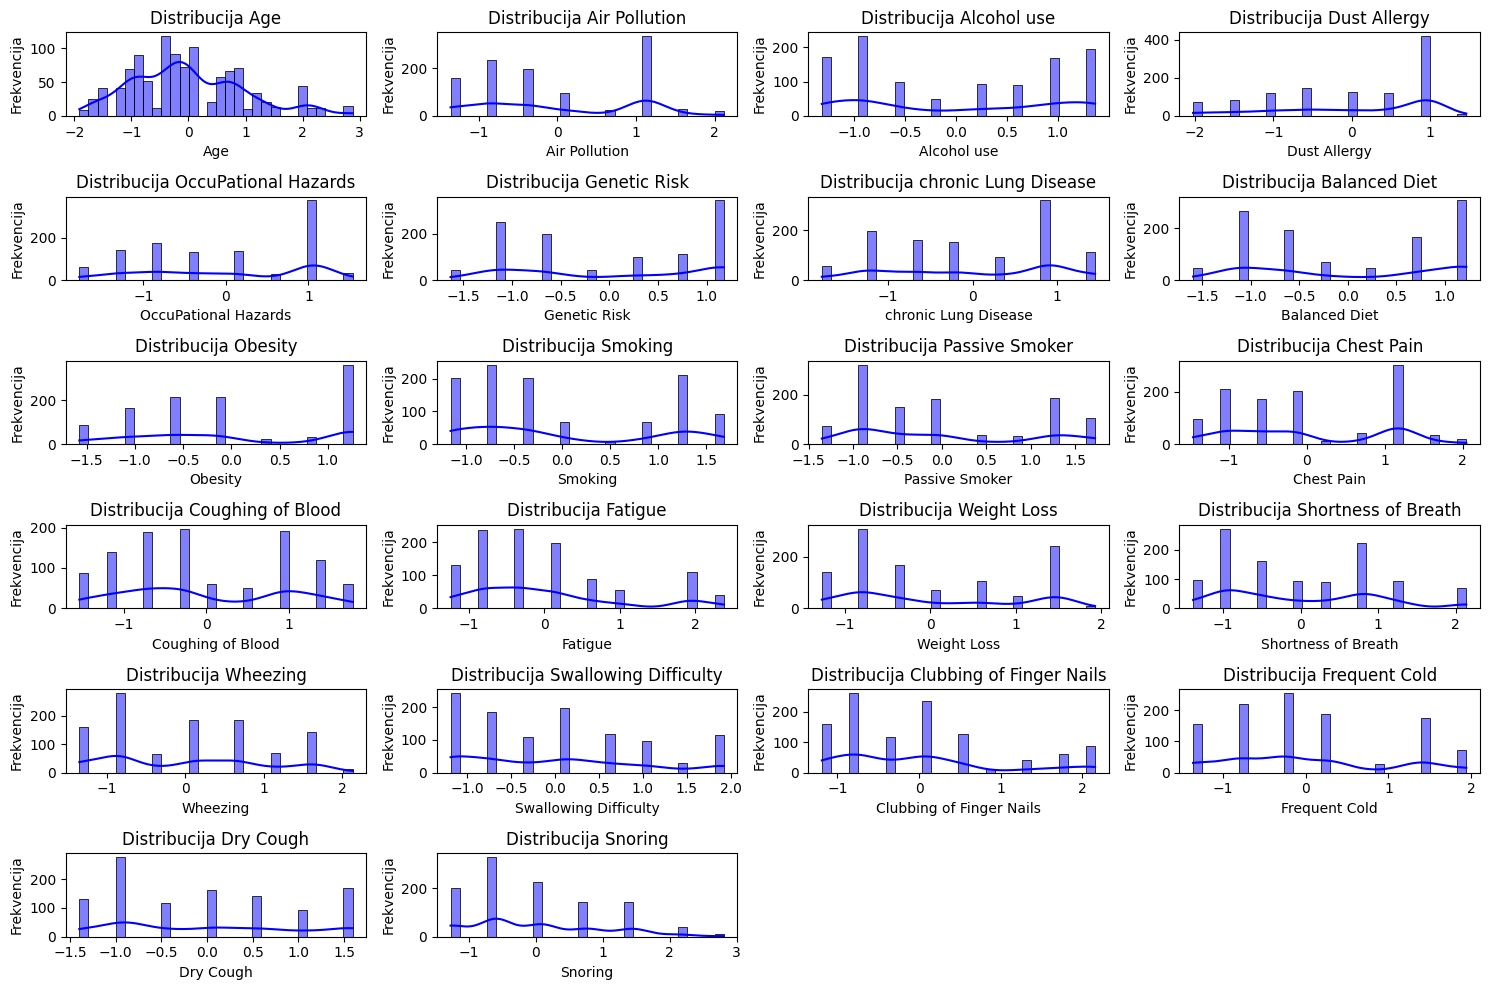

In [ ]:
drow_hist_for_num_columns(data_combined, numerical_columns)

Vidimo da su vrednosti mnogo manje(skaliranje, tj imaju drugaciji opseg sada). To ce mnogo pomoci modelima da lakse/efikasnije uce/obrade podatke.  

### 3.3.Feature selection

Odaberite najbintije faktore za modelovanje koristeći metode poput univariate selection-a.

**Univariate selection** je tehnika za odabir najvaznijih ulaznih promenljivih (features `X`) na osnovu njihove individualne statisticke veze sa ciljnom promenljivom (target `y`). Ova metoda analizira svaku ulaznu promenljivu pojedinacno kako bi procenila njen znacaj za predikciju ciljne promenljive.

Koristi se u procesima odabira karakteristika (feature selection), kada želimo:

1. Da smanjimo broj ulaznih promenljivih.
2. Da poboljsamo performanse modela uklanjanjem nevaznih karakteristika.
3. Da ubrzamo treniranje modela i povecamo njegovu interpretabilnost/razumljivost.

Kako funkcioniše univariate selection?

- Za svaku ulaznu promenljivu meri se njena korelacija/povezanost sa ciljnom promenljivom pomocu odgovarajuceg statističkog testa.
    - Neki od testova koje mi mozemo da koristimo na naseim podacima su:
      1. ANOVA F-Test
      2. Mutual Information

Svaka ulazna promenljiva dobija ocenu znacaja (p-vrednost ili neki skor).
Promenljive sa visokim znacjem (niskom p-vrednoscu) se zadrzavaju, dok se manje znacajne uklanjaju.



In [ ]:
# Kreiracemo funkciju sa parametrom "score_func" koji ce biti kakav statisticki test zelimo
# i paraketar "k" koji ce nam pomoci da izaberemo top k paremetra koji su najvazniji

def feature_selections(score_func, X, y, k):
  # Odabir najboljih karakteristika koristeći ANOVA F-test
  best_features = SelectKBest(score_func=score_func, k=k)  # Biramo top 5 karakteristika
  fit = best_features.fit(X, y)

  # Rezultati (scores)
  feature_scores = pd.DataFrame({
      'Feature': X.columns,
      'Score': fit.scores_
  }).sort_values(by='Score', ascending=False)

  return feature_scores.reset_index(drop=True).head(k)


In [ ]:
# Za ANOVA F-Test
f_test = feature_selections(f_classif, X, y, 10)

f_test

,Feature,Score
0,Obesity,1271.707647
1,Coughing of Blood,1082.277304
2,Passive Smoker,772.873976
3,Balanced Diet,678.601854
4,Dust Allergy,605.954118
5,Alcohol use,583.322450
6,Genetic Risk,512.362408
7,Air Pollution,498.176986
8,Chest Pain,433.555416
9,OccuPational Hazards,433.498625


In [ ]:
# Za Mutual Information
mutual_info = feature_selections(mutual_info_classif, X, y, 10)

mutual_info

,Feature,Score
0,Passive Smoker,0.604156
1,Coughing of Blood,0.569523
2,Alcohol use,0.551842
3,Obesity,0.538559
4,Wheezing,0.510449
5,Chest Pain,0.505744
6,Dust Allergy,0.485121
7,Shortness of Breath,0.457705
8,Balanced Diet,0.452608
9,OccuPational Hazards,0.416722


Izmedju ova dva smatram da je bolje izabrao `f_test` kljucne aspekte rizika za bolest/rak pluca, a to su kolone:
1. Gojaznost
2. Iskasljavanje krvi
3. Pasivni Pušač            
4. Izbalansirana Ishrana    
5. Alergija na Prašinu      
6. Upotreba Alkohola        
7. Genetski Rizik           
8. Zagađenje Vazduha        
9. Bol u Grudima            
10. Profesionalni Rizici     


In [ ]:
# Selekcija samo top 10 (izabrali smo da k=10) karakteristika
top_10_features = f_test['Feature']  # Samo imena karakteristika iz top 10

# Kreiraj novi DataFrame sa samo top 10 karakteristikama
X_top_10 = X[top_10_features]

# Proveri nove podatke
X_top_10.head()

,Obesity,Coughing of Blood,Passive Smoker,Balanced Diet,Dust Allergy,Alcohol use,Genetic Risk,Air Pollution,Chest Pain,OccuPational Hazards
0,-0.159458,-0.299122,-0.911856,-1.123275,-0.032279,-0.169221,-0.695362,-0.863580,-1.017440,-0.357085
1,-1.103275,-0.713728,-0.033683,-1.123275,-0.032279,-1.320136,-0.227083,-0.366931,-1.017440,-0.829887
2,1.256268,1.359303,-0.472770,0.752419,0.465544,0.214417,0.241196,0.129718,-0.141578,0.115718
3,1.256268,1.359303,1.283575,1.221343,0.963367,0.981694,0.709474,1.619666,1.172216,1.061323
4,1.256268,1.773909,1.283575,1.221343,0.963367,1.365332,1.177753,1.123017,1.172216,1.061323


In [ ]:
# Ovako izgledaju nasa ciljana kolona
y.head()

,Level
0,1
1,2
2,0
3,0
4,0


### 3.4.Podela podataka

Podelite podatke na trening i test set (npr. 80%-20%).

In [ ]:
# Podela na trening i test set (80% za trening, 20% za test)
X_train, X_test, y_train, y_test = train_test_split(X_top_10, y, test_size=0.3, random_state=42) # izbracemo 30% za test

# Prikazivanje veličina trening i test setova
print(f"Trening set: {X_train.shape}, Test set: {X_test.shape}")

Trening set: (766, 10), Test set: (329, 10)


## 4.Izbor i obuka modela

### 4.1.Testiranje različite algoritme za klasifikaciju

Napravicemo funkciju koja ce nam pomoci u kreiranju i treniranju modela, imacemo parameter `model` koji je model koji  zelimo da koristimo. Imamo i parametre `X_train, X_test, y_train, y_test` koji su podaci koje koristimo za trrening i test modela

In [ ]:
# Kreiracemo jednu funkciju koja ce nam pomoci da treniramo razlicite modele
def train_and_eval_my_model(model, X_train, X_test, y_train, y_test):
    res = {}
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Evaluacija metrika
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')  # 'weighted' za više klasa
    recall = recall_score(y_test, y_pred, average='weighted')        # Isto kao gore
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Izveštaj o klasifikaciji
    print("\nIzveštaj o klasifikaciji:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("\nMatrica konfuzije")
    print(conf_matrix)

    results = {"Accuracy": f"{accuracy*100:.0f}%",
               "Precision": f"{precision*100:.0f}%",
               "Recall": f"{recall*100:.0f}%",
               "f1": f"{f1*100:.0f}%"}
    print(results)
    return model

#### Logistic Regression

In [ ]:
# Deklaracija Base line modela
logistic_regression = LogisticRegression(random_state=42)

# Treinig modela i ispis evaluacije
logistic_regression = train_and_eval_my_model(logistic_regression, X_train, X_test, y_train, y_test)


Izveštaj o klasifikaciji:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       111
           1       0.73      0.77      0.75       105
           2       0.77      0.70      0.73       113

    accuracy                           0.82       329
   macro avg       0.82      0.82      0.82       329
weighted avg       0.82      0.82      0.82       329


Matrica konfuzije
[[111   0   0]
 [  0  81  24]
 [  4  30  79]]
{'Accuracy': '82%', 'Precision': '82%', 'Recall': '82%', 'f1': '82%'}


#### Random Forest

In [ ]:
# Kreiranje Random Forest modela
random_forest = RandomForestClassifier(random_state=42)

# Treinig modela i evaluacija
random_forest = train_and_eval_my_model(random_forest, X_train, X_test, y_train, y_test)


Izveštaj o klasifikaciji:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       111
           1       1.00      1.00      1.00       105
           2       1.00      1.00      1.00       113

    accuracy                           1.00       329
   macro avg       1.00      1.00      1.00       329
weighted avg       1.00      1.00      1.00       329


Matrica konfuzije
[[111   0   0]
 [  0 105   0]
 [  0   0 113]]
{'Accuracy': '100%', 'Precision': '100%', 'Recall': '100%', 'f1': '100%'}


#### Support Vector Machines (SVM)

In [ ]:
# Kreiranje SVM modela
svm_model = SVC(random_state=42, kernel="linear", probability=True) # Parametr koji smo stavili na True omogucava izracunavanje verovatnoca za svaku klasu

# Treinig modela i evaluacija
svm_model = train_and_eval_my_model(svm_model, X_train, X_test, y_train, y_test)


Izveštaj o klasifikaciji:

              precision    recall  f1-score   support

           0       0.93      1.00      0.97       111
           1       0.85      0.90      0.87       105
           2       0.93      0.81      0.87       113

    accuracy                           0.90       329
   macro avg       0.90      0.90      0.90       329
weighted avg       0.90      0.90      0.90       329


Matrica konfuzije
[[111   0   0]
 [  4  94   7]
 [  4  17  92]]
{'Accuracy': '90%', 'Precision': '90%', 'Recall': '90%', 'f1': '90%'}


#### XGBoost

In [ ]:
xgb_model = XGBClassifier(objective='multi:softprob',  # Za višeklasnu klasifikaciju
                          num_class=3)

# Treinig modela i evaluacija
xgb_model = train_and_eval_my_model(xgb_model, X_train, X_test, y_train, y_test)


Izveštaj o klasifikaciji:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       111
           1       1.00      1.00      1.00       105
           2       1.00      1.00      1.00       113

    accuracy                           1.00       329
   macro avg       1.00      1.00      1.00       329
weighted avg       1.00      1.00      1.00       329


Matrica konfuzije
[[111   0   0]
 [  0 105   0]
 [  0   0 113]]
{'Accuracy': '100%', 'Precision': '100%', 'Recall': '100%', 'f1': '100%'}


### Tuning hiperparametara

Vidimo da su modeli `Random Forest`, `XGBoost` ostvraili **100%** tacnost u poredjenju sa modelima `Logistic Regression`(**82%**) i `SVM`(**90%**). Tako da cemo pookusati da menjanjem hiper parametara ostvarimo bolju tacnost za ta modela.

#### Logistic Regression

Mozemo rucno da menjamo parametre ali efikasnije je da napravimo to pomocu  `Grid Search`-a koji pomaze da sistematski testiramo hiperparametre.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definicija hiperparametara za Grid Search
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200],
    'l1_ratio': [0.5]
}

# Kreiraj instancu Logistic Regression modela
logistic_regression = LogisticRegression(random_state=42)

# Grid Search
grid_search = GridSearchCV(estimator=logistic_regression, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

# Prikaz najboljih hiperparametara
print(f"Najbolji parametri: {grid_search.best_params_}")
print(f"Najbolja tacnost na trening skupu: {grid_search.best_score_:.2f}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_

Najbolji parametri: {'C': 100, 'l1_ratio': 0.5, 'max_iter': 200, 'penalty': 'l1', 'solver': 'saga'}
Najbolja tacnost na trening skupu: 0.89


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  

Vidimo da najbolje sto mozemo je:
```
Najbolji parametri: {'C': 100, 'l1_ratio': 0.5, 'max_iter': 200, 'penalty': 'l1', 'solver': 'saga'}
Najbolja tacnost na trening skupu: 0.89
```

Tako da cemo podesiti te paraketre

In [ ]:
# Deklaracija Base line modela
logistic_regression = LogisticRegression(random_state=42,
                                         C=100,
                                         l1_ratio=0.5,
                                         max_iter=200,
                                         penalty='l1',
                                         solver='saga')

# Treinig modela i ispis evaluacije
logistic_regression = train_and_eval_my_model(logistic_regression, X_train, X_test, y_train, y_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Izveštaj o klasifikaciji:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       111
           1       0.84      0.84      0.84       105
           2       0.85      0.85      0.85       113

    accuracy                           0.90       329
   macro avg       0.90      0.90      0.90       329
weighted avg       0.90      0.90      0.90       329


Matrica konfuzije
[[111   0   0]
 [  0  88  17]
 [  0  17  96]]
{'Accuracy': '90%', 'Precision': '90%', 'Recall': '90%', 'f1': '90%'}


#### Support Vector Machines (SVM)


In [ ]:
# Definisanje mreže hiperparametara
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]
}

# Kreiranje modela
svm_model = SVC(random_state=42, probability=True)

# Grid Search
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

# Prikaz najboljih hiperparametara
print(f"Najbolji parametri: {grid_search.best_params_}")
print(f"Najbolja tacnost na trening skupu: {grid_search.best_score_:.2f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Najbolji parametri: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Najbolja tacnost na trening skupu: 1.00


Vidimo da najbolje sto mozemo je:

```
Najbolji parametri: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Najbolja tacnost na trening skupu: 1.00
```

Tako da cemo podesiri te parametre

In [ ]:
# Kreiranje SVM modela
svm_model = SVC(random_state=42,
                kernel="linear", # necemo ga staviti na 'rbf' zato sto kasnije necemo moci da vidimo koji parametri su bili najuticajniji za predvidjanje
                probability=True,
                C=10,
                degree=2,
                gamma='scale',
                )

# Treinig modela i evaluacija
svm_model = train_and_eval_my_model(svm_model, X_train, X_test, y_train, y_test)


Izveštaj o klasifikaciji:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       111
           1       0.85      0.90      0.87       105
           2       0.90      0.85      0.87       113

    accuracy                           0.91       329
   macro avg       0.91      0.91      0.91       329
weighted avg       0.92      0.91      0.91       329


Matrica konfuzije
[[111   0   0]
 [  0  94  11]
 [  0  17  96]]
{'Accuracy': '91%', 'Precision': '92%', 'Recall': '91%', 'f1': '91%'}


Zato sto je `kernel="linear"` nemamo potpunu tacnost (opala nam je tacnost sa 100% na 91%). U slucaju kada zelimo da ovaj model koristimo mozemo staviti `kernel="rbf"`i dobicemo 100% tacnost.

### 4.2.Metode validacije

`k-fold cross-validation` za procenu performansi modela.

In [ ]:
# Napravicemo jedan python dikcionar u kome cemo da stavimo ime i instance svih modela
# da bi mogli lakse da procenimo performanu svakog na efikacniji nacin
models = {
    "Logistic Regression": logistic_regression,
    "Random forest": random_forest,
    "Support Vector Machines": svm_model
}

In [ ]:
def cross_val_score_for_model(models, X, y, cv=5, scoring="accuracy"):
  cross_validation_res = {}

  for model_name, model in models.items():
    score = cross_val_score(model, X, y, cv=cv, scoring=scoring)

    cross_validation_res[model_name] = f"{score.mean() * 100:.2f}%"

  print(f"{cross_validation_res}")

In [ ]:
cross_val_score_for_model(models, X, y)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:348: Convergen

{'Logistic Regression': '100.00%', 'Random forest': '100.00%', 'Support Vector Machines': '100.00%'}


Posto kada koristimo `cross_val_score` na XGBoost model dobijamo problem kompatibilnosti izmedju verzije XGBoost i Scikit-learn. XGBoost modeli u trenutnoj verziji ne implementiraju metodu `__sklearn_tags__`.

Tacnije dobijamo ovu gresku:

```
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The XGBClassifier or classes from which it inherits use _get_tags and _more_tags. Please define the __sklearn_tags__ method, or inherit from sklearn.base.BaseEstimator and/or other appropriate mixins such as sklearn.base.TransformerMixin, sklearn.base.ClassifierMixin, sklearn.base.RegressorMixin, and sklearn.base.OutlierMixin. From scikit-learn 1.7, not defining __sklearn_tags__ will raise an error.
  warnings.warn(
---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
<ipython-input-59-6f3d7b084b7a> in <cell line: 1>()
----> 1 cross_val_score_for_model(models, X_test_scaled, y_test)

7 frames
/usr/local/lib/python3.10/dist-packages/sklearn/base.py in __sklearn_tags__(self)
    538
    539     def __sklearn_tags__(self):
--> 540         tags = super().__sklearn_tags__()
    541         tags.estimator_type = "classifier"
    542         tags.classifier_tags = ClassifierTags()

AttributeError: 'super' object has no attribute '__sklearn_tags__'
```

Takodje smo probli da abdejtujemo ScikLearn i XGBoost sa komandom `pip install --upgrade xgboost scikit-learn
` ali nije resilo problem.

Pa cemo zato napraviti nasu funkciju za kros-validaciju.

In [ ]:
from sklearn.model_selection import StratifiedKFold

def my_cross_val_score(X_train, y_train, cv=5):
  # Kros-validacija
  kf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
  scores = []

  for train_idx, test_idx in kf.split(X_train, y_train):
    X_train_cv, X_test_cv = X_train[train_idx], X_train[test_idx]
    y_train_cv, y_test_cv = y_train[train_idx], y_train[test_idx]

    xgb_model = XGBClassifier()
    xgb_model.fit(X_train_cv, y_train_cv)
    y_pred_cv = xgb_model.predict(X_test_cv)
    score = accuracy_score(y_test_cv, y_pred_cv)
    scores.append(score)

  print(f"Prosečna tacnost moje funkcije za kros-validaciju je: {np.mean(scores) * 100:.2f}%")


Prilikom pozivanja ove funkcije imacemo problem zato sto `X_train_scaled i y_train` nisu istog tipa podataka (`numpy` zato sto su nam `X` podaci tog tipa) pa cemo ih prvo pretvoriti da budu istog tipa.

In [ ]:
print(type(X_train))  # Treba da bude <class 'numpy.ndarray'>
print(type(y_train))  # Treba da bude <class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [ ]:
# Pretvaranje/Transformacija u numpy
X_train = np.array(X_train)
y_train = np.array(y_train)

In [ ]:
my_cross_val_score(X_train, y_train)

Prosečna tacnost moje funkcije za kros-validaciju je: 100.00%


---

## 5.Evaluacija modela

### 5.1.Analiza ROC krivu i AUC vrednost

**ROC Kriva**

ROC (Receiver Operating Characteristic) Predstavlja odnos izmedju:

1. *True Positive Rate (TPR)*, poznat i kao osetljivost ili senzitivnost, koji meri koliko dobro model prepoznaje pozitivne primere (stvarno pozitivne). Izracunava se kao:
$$
TPR = \frac{TP}{TP + FN}
$$
gde su:
- **TP**: True Positives (stvarno pozitivni tj stvarno bolesni)
- **FN**: False Negatives (lazno negativni tj bolesni ali model kaze da su zdravi)

2. *False Positive Rate (FPR)*, koji meri koliko cesto model pogresno oznacava negativne primere kao pozitivne (tj kaze da su bolesni a oni u stvrai nisu). Izracunava se kao:
$$
FPR = \frac{FP}{FP + TN}
$$
gde su:
- **FP**: False Positives (lazno pozitivni)
- **TN**: True Negatives (stvarno negativni)
---
**AUC (Area Under the Curve)**

AUC je numericka vrednost koja predstavlja povrsinu ispod ROC krive. Ova vrednost meri ukupnu sposobnost modela da razlikuje izmedju pozitivnih i negativnih klasa. Vrednosti AUC su izmedju 0 i 1.

- **AUC = 1.0**: Savrsen model koji nepogresivo razdvaja pozitivne i negativne klase.
- **AUC = 0.5**: Model koji ne razlikuje klase bolje od slucajnog pogadjanja, sto znaci da je performansa modela jednaka performansi nasumicnog klasifikatora.

In [ ]:
def plot_roc_auc_multiclass(model, X_test, y_test, class_names):
    # Binarizacija ciljne promenljive (za viseklasnu evaluaciju)
    y_test_bin = label_binarize(y_test, classes=range(len(class_names)))

    # Predikcija verovatnoća
    y_pred_prob = model.predict_proba(X_test)

    # Izračunavanje AUC vrednosti
    auc_scores = {}
    for i, class_name in enumerate(class_names):
        auc_scores[class_name] = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])

    macro_auc = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr', average='macro') # AUC se racuna za svaku klasu pojedinacno
    micro_auc = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr', average='micro') # Gleda se svaka instanca kao deo jedne velike binarne klasifikacije

    print(f"Macro AUC: {macro_auc:.2f}")
    print(f"Micro AUC: {micro_auc:.2f}")

    # Plotovanje ROC krivih
    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {class_name} (AUC = {auc_scores[class_name]:.2f})")

    plt.plot([0, 1], 'k--', label="Random Model (AUC = 0.5)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Multiclass)")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

In [ ]:
class_names = ["Low", "Medium", "High"]  # Nazivi nasih klasa

#### Logistic Regression



Macro AUC: 0.97
Micro AUC: 0.98


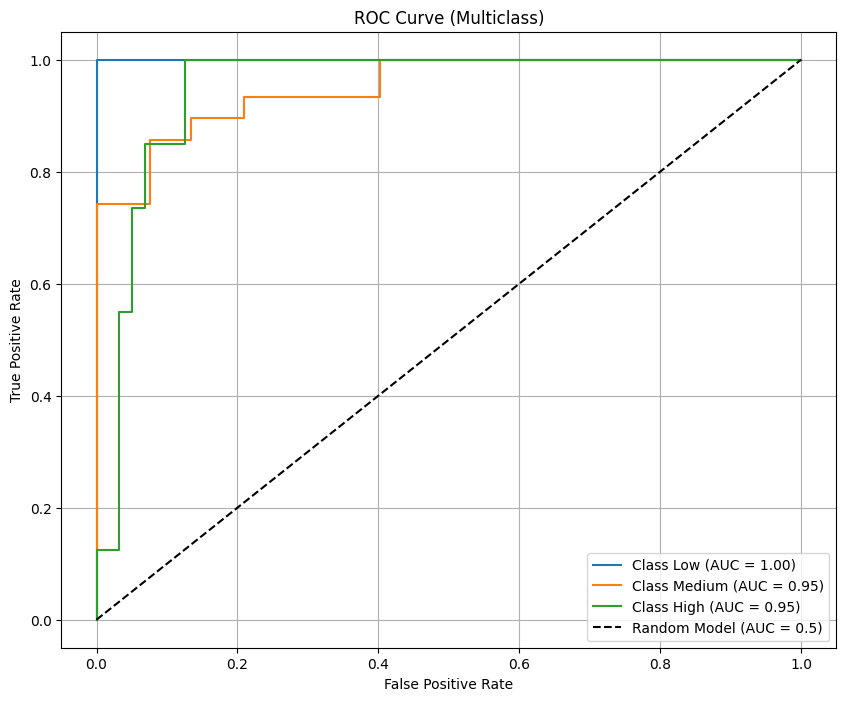

In [ ]:
# Poziv funkcije za ispis i crtanje
plot_roc_auc_multiclass(logistic_regression, X_test, y_test, class_names)

#### Random Forest

Macro AUC: 1.00
Micro AUC: 1.00


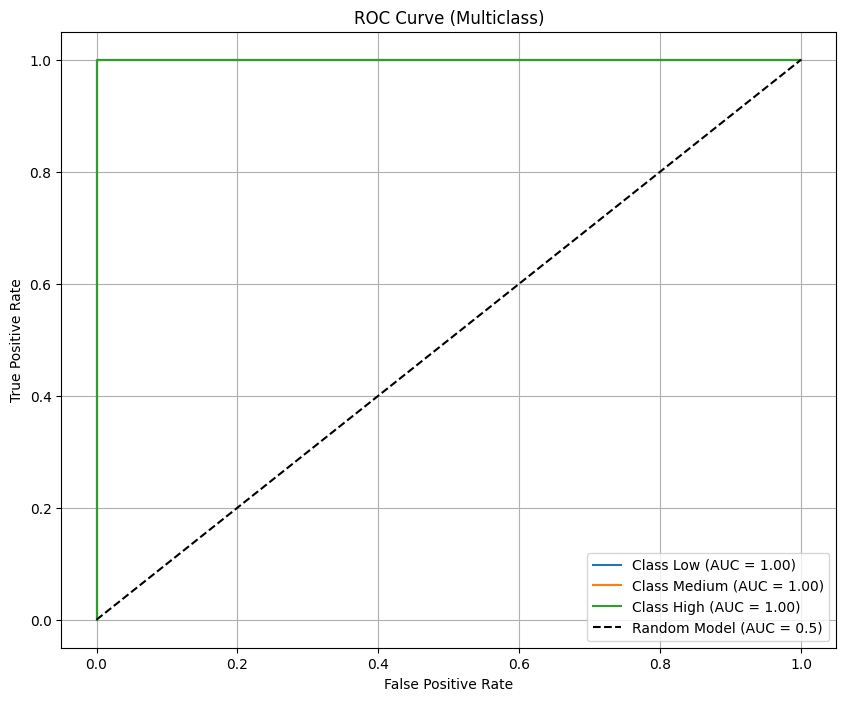

In [ ]:
plot_roc_auc_multiclass(random_forest, X_test, y_test, class_names)

#### Support Vector Machines (SVM)

Macro AUC: 0.96
Micro AUC: 0.97


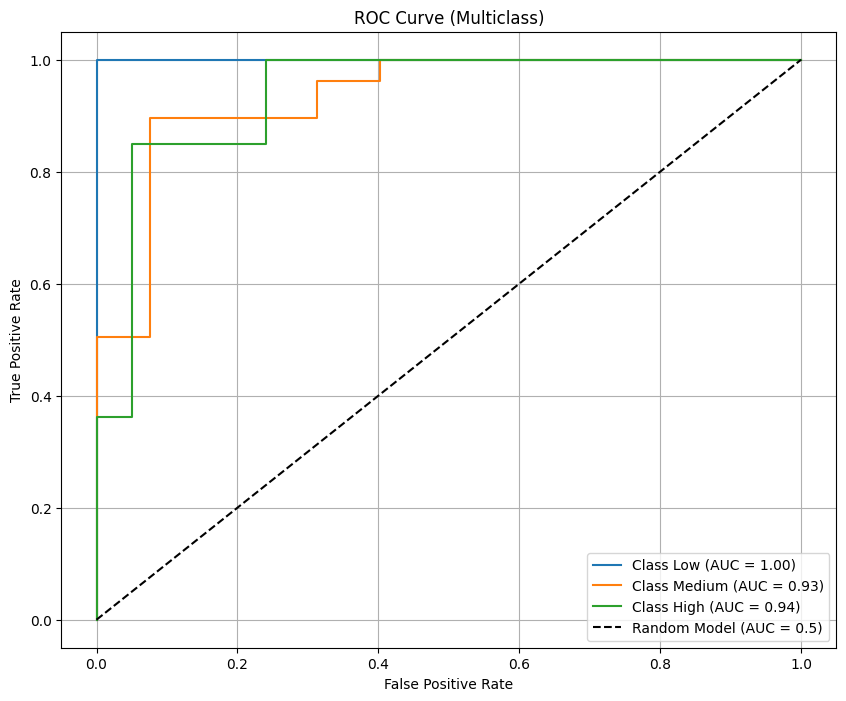

In [ ]:
plot_roc_auc_multiclass(svm_model, X_test, y_test, class_names)

#### XGBoost

Macro AUC: 1.00
Micro AUC: 1.00


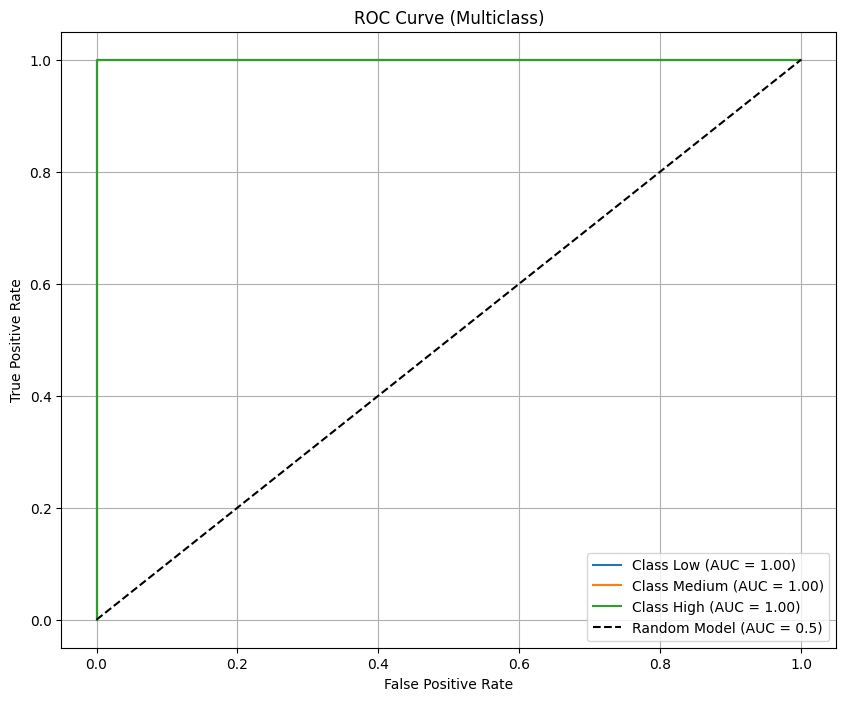

In [ ]:
plot_roc_auc_multiclass(xgb_model, X_test, y_test, class_names)

## 6.Interpretacija i vizualizacija rezultata

### 6.1.Kreiranje izvestaje i grafikona

Mozemo napraviti razlicite vizualizacije za prikaz rezultata modela i analizu podataka

In [ ]:
def confusion_matrix_display(model, X_test, y_test, class_names, cmap='Blues', xticks_rotation='vertical'):
    """
    Prikazuje konfuzionu matricu za dati model koristeći predikcije.
    """
    # Ručno generisanje predikcija
    y_pred = model.predict(X_test)

    # Kreiranje konfuzione matrice
    cm = confusion_matrix(y_test, y_pred)

    # Prikaz matrice
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap=cmap)
    plt.title("Confusion Matrix")
    plt.xticks(rotation=xticks_rotation)
    plt.show()


#### Logistic Regression


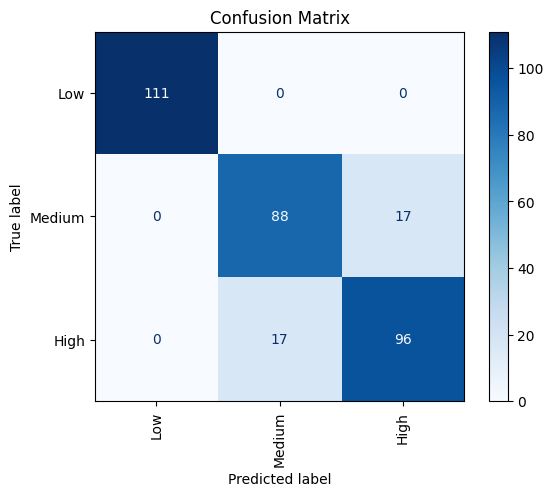

In [ ]:
confusion_matrix_display(logistic_regression, X_test, y_test, class_names)

#### Random Forest

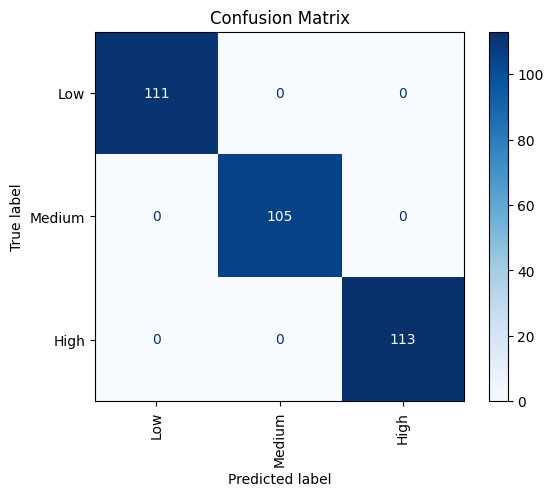

In [ ]:
confusion_matrix_display(random_forest, X_test, y_test, class_names)

#### Support Vector Machines (SVM)

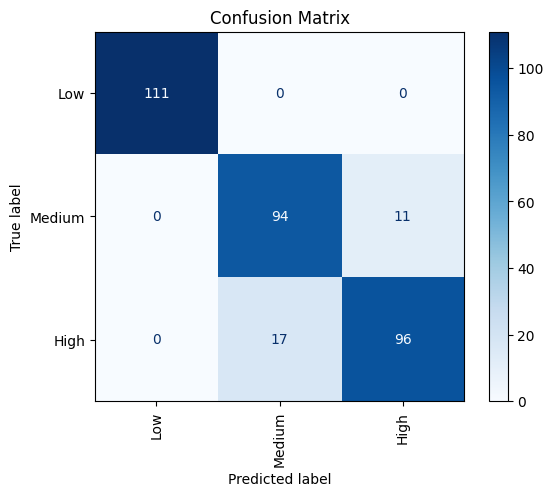

In [ ]:
confusion_matrix_display(svm_model, X_test, y_test, class_names)

#### XGBoost

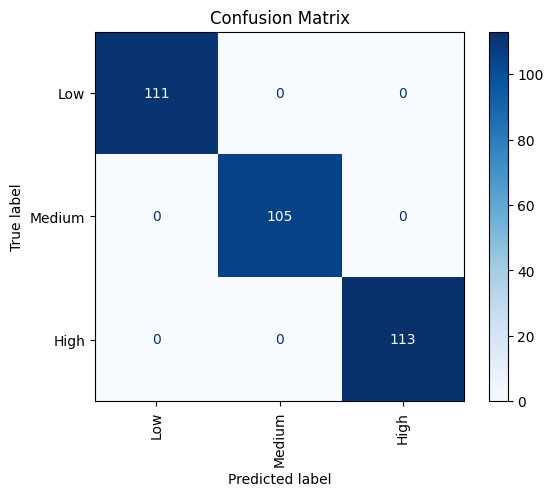

In [ ]:
confusion_matrix_display(xgb_model, X_test, y_test, class_names)

**Najbolje se pokazao model `Random Forest` i model `XGBoost` tako da bi neki od tih modela koristili u produkciji.**

----

Da vidimo kao vizuelno izgleda distribucija(rasoredjenost) nasih predvidjanja po klasama.

Kreiracemo funkciju da bi mogli da je pozivamo za svaki od nasih modela.

In [ ]:
def desplay_distribution(model, X_test):
  # Distribucija pokazuje kako su predikcije modela rasporedjene po klasama.
  y_pred = model.predict(X_test)

  # Prikaz distribucije
  sns.countplot(x=y_pred, hue=y_pred, order=[0, 1, 2], palette="cool", legend=False)
  plt.title("Distribucija Predikcija po Klasama")
  plt.xlabel("Klase")
  plt.ylabel("Broj Predikcija")
  plt.xticks(ticks=[0, 1, 2], labels=class_names)
  plt.show()

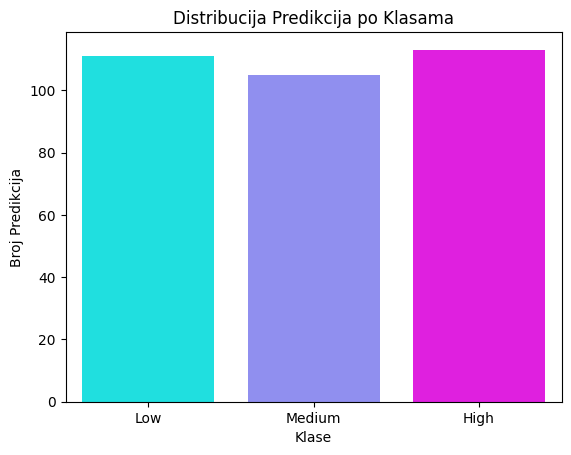

In [ ]:
# Logistic Regresion
desplay_distribution(logistic_regression, X_test)

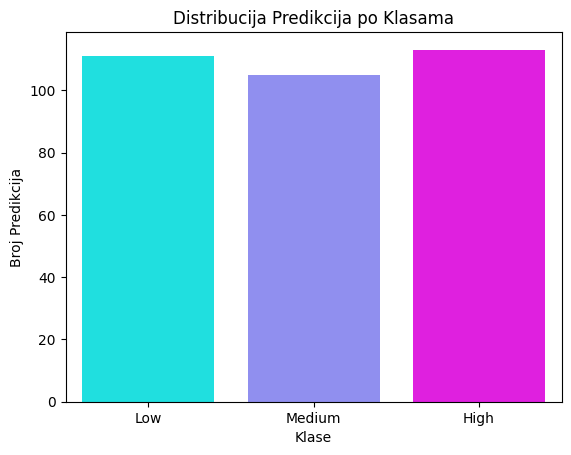

In [ ]:
# Random Forest
desplay_distribution(random_forest, X_test)

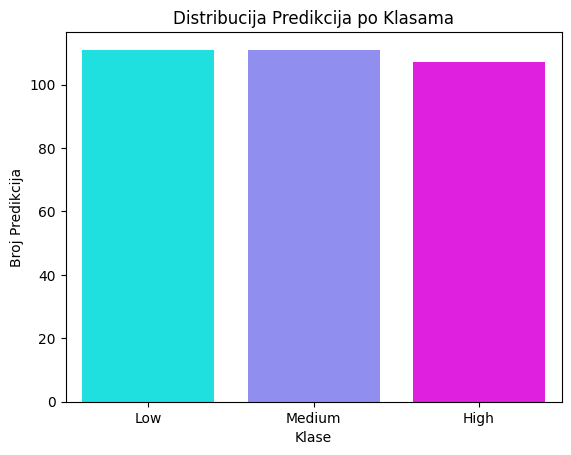

In [ ]:
# SVM
desplay_distribution(svm_model, X_test)

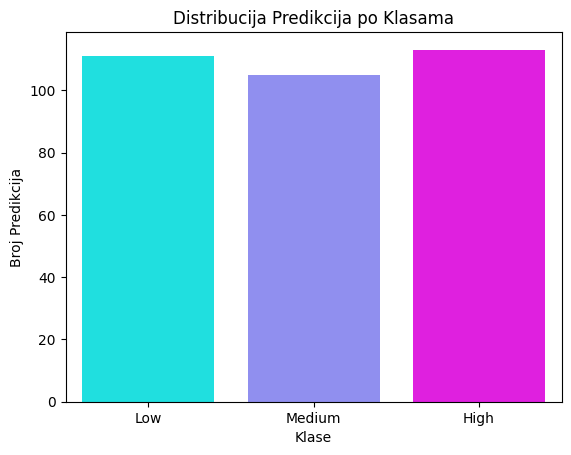

In [ ]:
# XGBoost
desplay_distribution(xgb_model, X_test)

### 6.2.Identifikacija kljucnih faktora

Mozda ce trebati da se transformisu X_train_scaled u DataFrame(numpy => tabele) zato sto mislim da treba koristim skalirane podatke

In [ ]:
def drow_coef(model, X_train, model_type='logistic_regression'):
    if model_type == 'logistic_regression' or model_type == 'svm':
        # Ekstrakcija koeficijenata za modele kao što je Logistic Regression ili Linear SVM
        coefficients = model.coef_  # Svaka klasa ima sopstvene koeficijente
        features = X_train.columns

        # Prosečan uticaj faktora (absolutna vrednost koeficijenata)
        avg_impact = np.mean(np.abs(coefficients), axis=0)

    elif model_type == 'random_forest' or model_type == 'xgboost':
        # Ekstrakcija važnosti karakteristika za modele Random Forest ili XGBoost
        if model_type == 'random_forest':
            importance = model.feature_importances_
        elif model_type == 'xgboost':
            importance = model.feature_importances_

        features = X_train.columns
        avg_impact = importance  # Veća vrednost označava veći uticaj

    else:
        raise ValueError("Nepodržan model. Podržani modeli: 'logistic_regression', 'svm', 'random_forest', 'xgboost'.")

    # Identifikacija najvažnijih faktora
    important_factors = sorted(zip(avg_impact, features), reverse=True)
    for impact, factor in important_factors:
        print(f"{factor}: {impact:.2f}")

    # Vizualizacija značaja faktora
    sns.barplot(x=avg_impact, y=features, palette="viridis")
    plt.title(f"Uticaj Faktora na Model: {model_type.replace('_', ' ').title()}")
    plt.xlabel("Prosečan Uticaj (Apsolutno)")
    plt.ylabel("Faktori")
    plt.show()


In [ ]:
# Posto su nam X vrednsoti numpy niz ne mozemo da ih iscrtamo pomocu nase funkcije drow_cooef() pa cemo ih transormisati u DataFrame(tabelu)
X_train = pd.DataFrame(standard_scaler(X_train), columns=X_test.columns) # Dacemo opet isto ime

#### Logistic Regression

Alcohol use: 8.23
Coughing of Blood: 5.92
Chest Pain: 5.01
Passive Smoker: 4.15
Dust Allergy: 3.38
OccuPational Hazards: 1.70
Genetic Risk: 1.04
Obesity: 1.03
Balanced Diet: 0.53
Air Pollution: 0.33


<ipython-input-92-13fa3ef9f63a>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_impact, y=features, palette="viridis")


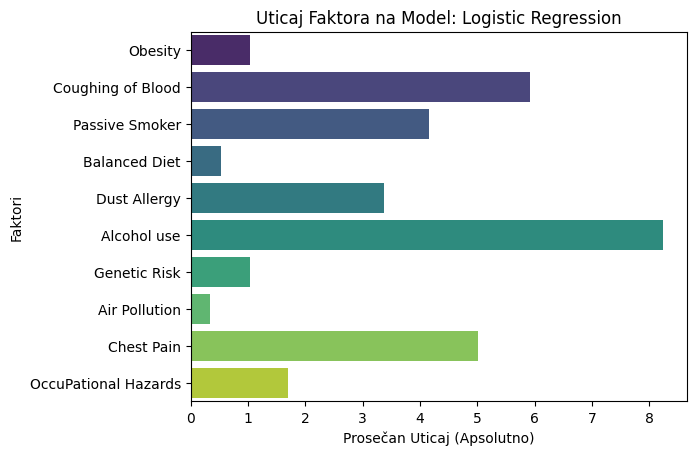

In [ ]:
drow_coef(logistic_regression, X_train, model_type="logistic_regression")

#### Random Forest

Coughing of Blood: 0.20
Obesity: 0.19
Passive Smoker: 0.14
Alcohol use: 0.11
Dust Allergy: 0.08
OccuPational Hazards: 0.07
Chest Pain: 0.07
Balanced Diet: 0.06
Genetic Risk: 0.05
Air Pollution: 0.04


<ipython-input-92-13fa3ef9f63a>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_impact, y=features, palette="viridis")


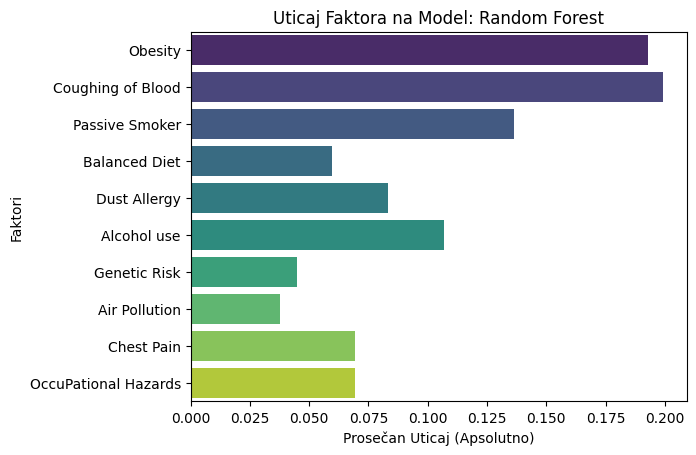

In [ ]:
drow_coef(random_forest, X_train, model_type="random_forest")

Mozemo da ispisemo sva stable pmocu koda:
```Python

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Loop through all the trees in the random forest
for i, tree in enumerate(random_forest.estimators_):
    plt.figure(figsize=(20, 10))
    plot_tree(
        tree,
        feature_names=X.columns,  # Replace with your feature names
        class_names=class_names,      # Replace with your class names
        filled=True
    )
    plt.title(f"Tree {i+1}")
    plt.show()

```

I tu cemo videti 100 individualna stabla koja koristi model `RandomForest()` model da bi napravio predvidjanje.


Napravicemo jednu funkciju koja ce nacrtati samo jedno stablo sa ideksa 'idx' koje koristimo unutar modela da bi napravili predvidjanje

In [ ]:
def print_random_forest_tree(idx=0, model=random_forest):
  tree = random_forest.estimators_[idx]  # Stablo koje koristimo

  plt.figure(figsize=(20, 10))
  plot_tree(
      tree,
      feature_names=X.columns,  # Ime kolona
      class_names=class_names,# Ime klasa
      filled=True
    )

  plt.title(f"Stablo {idx}")
  plt.show()

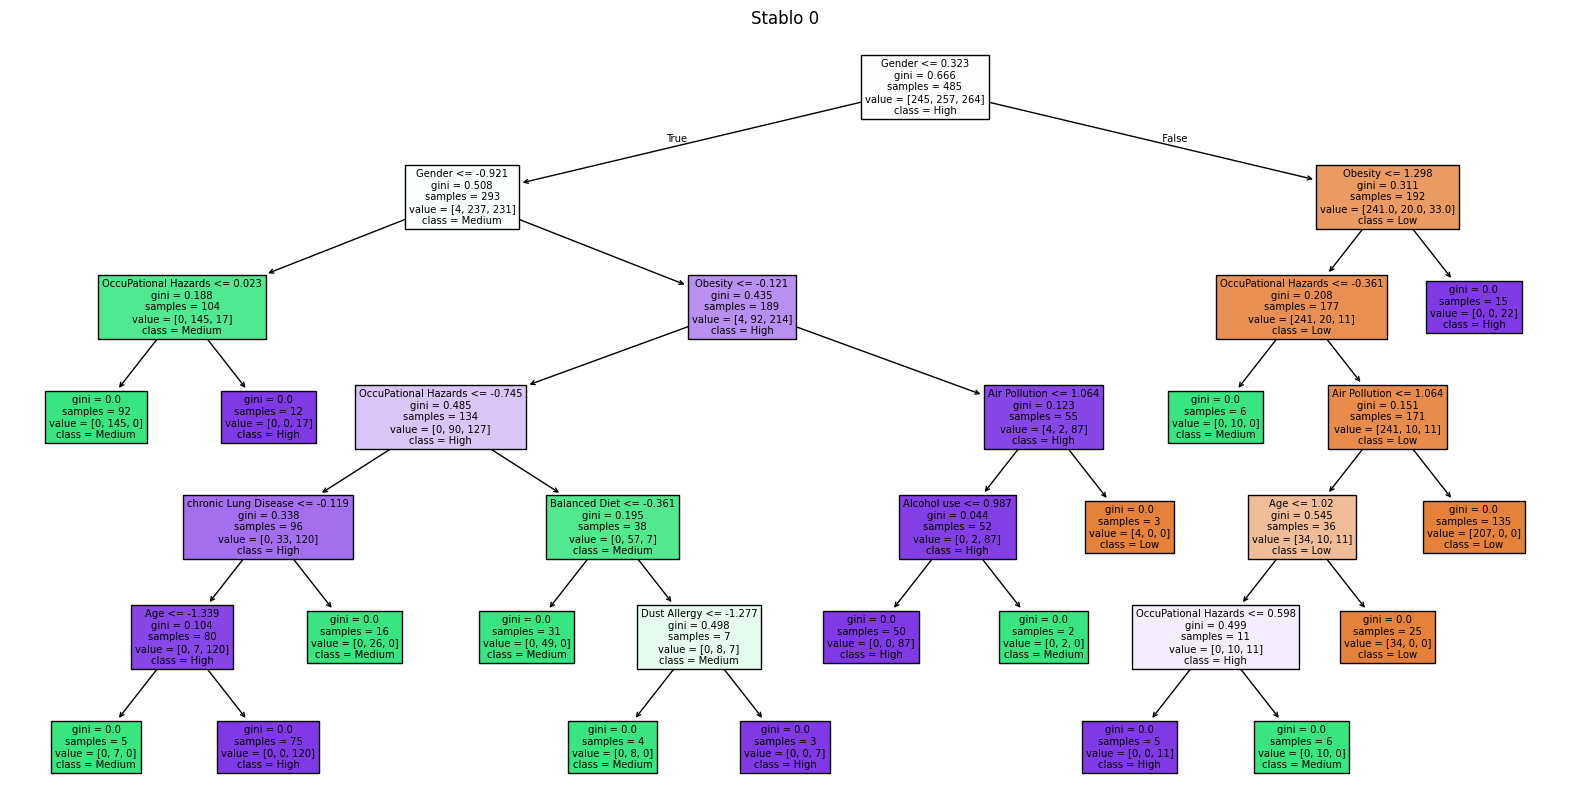

In [ ]:
print_random_forest_tree()

#### Support Vector Machine (SVM)

Chest Pain: 1.78
Obesity: 1.65
Coughing of Blood: 1.64
OccuPational Hazards: 1.17
Alcohol use: 1.00
Passive Smoker: 0.98
Dust Allergy: 0.93
Genetic Risk: 0.61
Air Pollution: 0.32
Balanced Diet: 0.12


<ipython-input-92-13fa3ef9f63a>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_impact, y=features, palette="viridis")


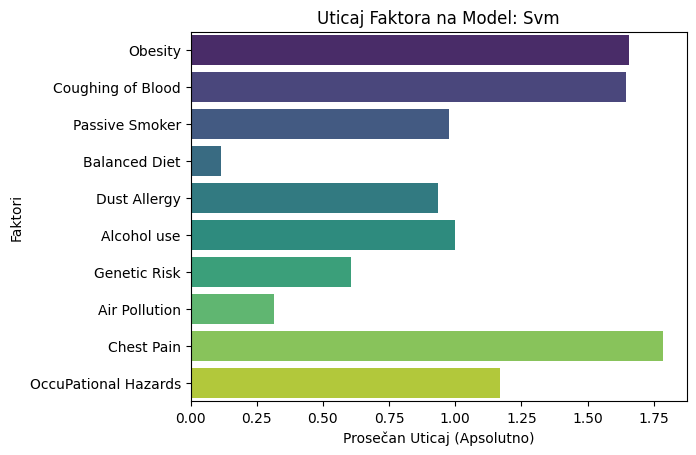

In [ ]:
drow_coef(svm_model, X_train, model_type="svm")

#### XGBoost

Coughing of Blood: 0.23
Passive Smoker: 0.23
Alcohol use: 0.23
OccuPational Hazards: 0.08
Air Pollution: 0.07
Obesity: 0.05
Dust Allergy: 0.05
Chest Pain: 0.03
Genetic Risk: 0.01
Balanced Diet: 0.01


<ipython-input-92-13fa3ef9f63a>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_impact, y=features, palette="viridis")


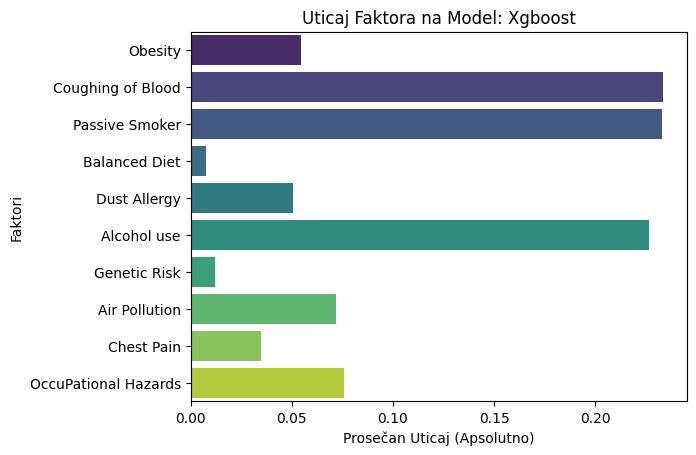

In [ ]:
drow_coef(xgb_model, X_train, model_type="xgboost")

In [ ]:
def plot_xgboost_tree(model, tree_idx=0, figsize=(20, 10)):
    """
    Plot a single tree from an XGBoost model.

    Parameters:
    - model: Trained XGBoost model.
    - tree_idx: Index of the tree to visualize.
    - figsize: Size of the plot (default is (20, 10)).
    """
    plt.figure(figsize=figsize)
    xgb.plot_tree(model, num_trees=tree_idx)
    plt.show()


<Figure size 2000x1000 with 0 Axes>

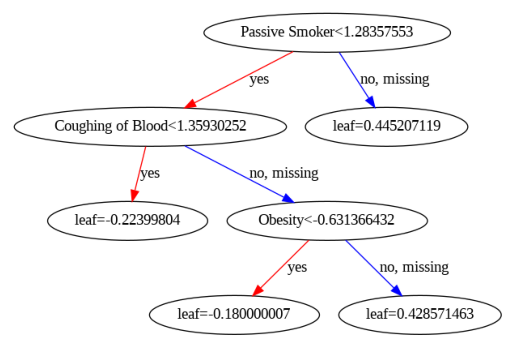

In [ ]:
plot_xgboost_tree(xgb_model, tree_idx=0, figsize=(20, 10))  # Iscrtavanje pvog stabla XGBoost modela